# MVTec AD 2 — Exploratory Data Analysis cho MS-ILA

**Đề tài:** *Thích ứng đặc trưng đa tỷ lệ bất biến chiếu sáng cho phân đoạn dị vật công nghiệp trên MVTec AD 2*  
**Mô hình nghiên cứu:** **MS-ILA · Multi-Scale Illumination-Invariant Lightweight Adapters**

Notebook gồm hai tầng:

1. **EDA chuẩn cho dataset thị giác**
   - cấu trúc category/split;
   - số lượng ảnh;
   - định dạng, resolution, aspect ratio, channel;
   - ảnh lỗi/corrupt;
   - normal/anomaly nếu path có nhãn công khai;
   - mask/ground-truth và image-mask pairing;
   - exact duplicate/checksum;
   - trực quan ảnh theo category/split.

2. **EDA chuyên sâu phục vụ MS-ILA**
   - định lượng illumination shift giữa `train`, `validation`, `test_public`, `test_private`, `test_private_mixed`;
   - luminance/chromaticity, clipping, dynamic range, local shading;
   - low-frequency illumination field vs high-frequency texture;
   - defect visibility dưới thay đổi chiếu sáng nếu có mask;
   - kích thước dị vật và khả năng sống sót khi downsample;
   - information retention ở các scale MS-ILA;
   - photometric-invariance proxy: single-scale vs multi-scale;
   - xuất CSV/JSON/Markdown để dùng cho `data_card`, protocol và paper.

Hỗ trợ cấu trúc Google Drive:

`data/<class_name>/<class_name>/{train,validation,test_public,test_private,test_private_mixed}/...`

Notebook **không hard-code tên class**.

## 0. Cấu hình

- Sửa `DATA_ROOT`.
- `FAST_MODE=True`: lấy mẫu cân bằng để chạy nhanh trên Colab.
- `FAST_MODE=False`: dùng nhiều ảnh hơn cho thống kê pixel.
- Bật `RUN_FULL_HASH_AUDIT=True` khi muốn checksum toàn bộ dataset.

In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False

from pathlib import Path

DATA_ROOT = Path('/content/drive/MyDrive/[Q3-4] 2026/[S7] Computer Vision/CV-Nhóm 9/data') if IN_COLAB else Path("./data")

OUTPUT_DIR = Path("./outputs/eda_msila")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_SPLITS = [
    "train",
    "validation",
    "test_public",
    "test_private",
    "test_private_mixed",
]

SEED = 42
FAST_MODE = True

MAX_PIXEL_IMAGES_PER_GROUP = 40 if FAST_MODE else None
MAX_ADVANCED_IMAGES_PER_GROUP = 12 if FAST_MODE else 50

RUN_FULL_HASH_AUDIT = False
HASH_ALGO = "md5"

MSILA_SCALES = [0.30, 0.40, 0.50, 0.60, 0.70]

print("DATA_ROOT :", DATA_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

Mounted at /content/drive
DATA_ROOT : /content/drive/MyDrive/[Q3-4] 2026/[S7] Computer Vision/CV-Nhóm 9/data
OUTPUT_DIR: /content/outputs/eda_msila


## 1. Import thư viện và thiết lập tái lập

In [ ]:
import os
import re
import math
import json
import random
import hashlib
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import cv2
from scipy.stats import wasserstein_distance, spearmanr
from scipy.spatial.distance import jensenshannon

try:
    from skimage.measure import label as sk_label, regionprops
    from skimage.metrics import structural_similarity as ssim
    SKIMAGE_OK = True
except Exception:
    SKIMAGE_OK = False

warnings.filterwarnings("ignore")
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

print("OpenCV:", cv2.__version__)
print("scikit-image available:", SKIMAGE_OK)

OpenCV: 4.14.0
scikit-image available: True


## 2. Quy tắc nhận diện ảnh, split và mask

Scanner tìm split dựa trên **thành phần đường dẫn**, vì vậy vẫn hoạt động khi có hai lớp thư mục lặp lại như `data/can/can/train/...`.

Mask được nhận diện theo các token phổ biến `ground_truth`, `mask`, `masks`, `gt` hoặc hậu tố `_mask`, `_gt`.

In [ ]:
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

MASK_DIR_TOKENS = {
    "ground_truth", "groundtruth", "gt", "mask", "masks",
    "segmentation", "segmentations", "label", "labels"
}

NORMAL_TOKENS = {"good", "normal", "ok", "healthy", "negative", "no_anomaly"}
ANOMALY_TOKENS = {"anomaly", "anomalous", "defect", "defective", "bad", "positive"}

def normalize_token(x):
    return re.sub(r"[\s\-]+", "_", str(x).strip().lower())

SPLIT_ALIASES = {
    "train": "train",
    "training": "train",
    "val": "validation",
    "valid": "validation",
    "validation": "validation",
    "test_public": "test_public",
    "testpublic": "test_public",
    "public_test": "test_public",
    "test_private": "test_private",
    "testprivate": "test_private",
    "private_test": "test_private",
    "test_private_mixed": "test_private_mixed",
    "testprivatemixed": "test_private_mixed",
    "private_mixed": "test_private_mixed",
}

def canonical_split(part):
    return SPLIT_ALIASES.get(normalize_token(part))

def is_mask_path(path):
    parts = [normalize_token(p) for p in path.parts]
    stem = normalize_token(path.stem)
    return (
        any(p in MASK_DIR_TOKENS for p in parts)
        or stem.endswith("_mask")
        or stem.endswith("_gt")
        or stem.endswith("_label")
    )

def infer_status_from_path(rel_parts, split_idx):
    tokens = [normalize_token(p) for p in rel_parts[split_idx + 1:-1]]
    if any(t in NORMAL_TOKENS for t in tokens):
        return "normal"
    if any(t in ANOMALY_TOKENS for t in tokens):
        return "anomaly"
    return "unknown"

## 3. Quét dataset → `manifest`

`manifest` là bảng trung tâm: một dòng cho mỗi file ảnh/mask.

In [ ]:
assert DATA_ROOT.exists(), (
    f"Không tìm thấy {DATA_ROOT}. Hãy sửa DATA_ROOT ở Cell 0."
)

all_files = [
    p for p in DATA_ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS
]

records = []

for p in tqdm(all_files, desc="Scanning dataset"):
    rel = p.relative_to(DATA_ROOT)
    parts = list(rel.parts)

    split = "unresolved"
    split_idx = None

    for i, part in enumerate(parts):
        s = canonical_split(part)
        if s is not None:
            split = s
            split_idx = i
            break

    category = parts[0] if parts else "unknown"
    subgroup = ""
    status_hint = "unknown"

    if split_idx is not None:
        subgroup = "/".join(parts[split_idx + 1:-1])
        status_hint = infer_status_from_path(parts, split_idx)

    records.append({
        "path": str(p),
        "rel_path": str(rel),
        "category": category,
        "split": split,
        "subgroup": subgroup,
        "filename": p.name,
        "stem": p.stem,
        "ext": p.suffix.lower(),
        "is_mask": is_mask_path(p),
        "status_hint": status_hint,
        "size_bytes": p.stat().st_size,
    })

manifest = pd.DataFrame(records)
manifest.to_csv(OUTPUT_DIR / "manifest_raw.csv", index=False)

images_manifest = manifest[~manifest["is_mask"]].copy()
masks_manifest = manifest[manifest["is_mask"]].copy()

print(f"Files detected : {len(manifest):,}")
print(f"Images         : {len(images_manifest):,}")
print(f"Masks heuristic: {len(masks_manifest):,}")
display(manifest.head())

Scanning dataset:   0%|          | 0/9500 [00:00<?, ?it/s]

Files detected : 9,500
Images         : 8,734
Masks heuristic: 766


,path,rel_path,category,split,subgroup,filename,stem,ext,is_mask,status_hint,size_bytes
0,/content/drive/MyDrive/[Q3-4] 2026/[S7] Comput...,fruit_jelly/test_private_mixed/091_mixed.png,fruit_jelly,test_private_mixed,,091_mixed.png,091_mixed,.png,False,unknown,1451015
1,/content/drive/MyDrive/[Q3-4] 2026/[S7] Comput...,fruit_jelly/test_private_mixed/054_mixed.png,fruit_jelly,test_private_mixed,,054_mixed.png,054_mixed,.png,False,unknown,1448692
2,/content/drive/MyDrive/[Q3-4] 2026/[S7] Comput...,fruit_jelly/test_private_mixed/156_mixed.png,fruit_jelly,test_private_mixed,,156_mixed.png,156_mixed,.png,False,unknown,1384671
3,/content/drive/MyDrive/[Q3-4] 2026/[S7] Comput...,fruit_jelly/test_private_mixed/097_mixed.png,fruit_jelly,test_private_mixed,,097_mixed.png,097_mixed,.png,False,unknown,1505548
4,/content/drive/MyDrive/[Q3-4] 2026/[S7] Comput...,fruit_jelly/test_private_mixed/247_mixed.png,fruit_jelly,test_private_mixed,,247_mixed.png,247_mixed,.png,False,unknown,1495386


## 4. Audit cấu trúc category/split

In [ ]:
categories = sorted(images_manifest["category"].dropna().unique().tolist())
splits_found = sorted(images_manifest["split"].dropna().unique().tolist())

print("Categories :", categories)
print("Splits     :", splits_found)

structure = (
    images_manifest.groupby(["category", "split"])
    .size()
    .unstack(fill_value=0)
)

for s in EXPECTED_SPLITS:
    if s not in structure.columns:
        structure[s] = 0

ordered = EXPECTED_SPLITS + [c for c in structure.columns if c not in EXPECTED_SPLITS]
display(structure[ordered])

unresolved = manifest[manifest["split"] == "unresolved"]
print("Unresolved files:", len(unresolved))
if len(unresolved):
    display(unresolved.head(50))

Categories : ['can', 'fabric', 'fruit_jelly', 'rice', 'sheet_metal', 'vial', 'wallplugs', 'walnuts']
Splits     : ['test_private', 'test_private_mixed', 'test_public', 'train', 'validation']


split,train,validation,test_public,test_private,test_private_mixed
category,,,,,
can,412,46,162,321,321
fabric,387,43,156,314,314
fruit_jelly,366,74,160,510,510
rice,313,35,132,277,277
sheet_metal,137,19,114,142,142
vial,291,41,140,276,276
wallplugs,293,33,150,232,232
walnuts,432,48,150,228,228


Unresolved files: 0


## 5. Metadata ảnh: resolution, aspect ratio, mode, channel, file format, corrupt

In [ ]:
def read_basic_metadata(path_str):
    out = {
        "read_ok": False,
        "width": np.nan,
        "height": np.nan,
        "aspect_ratio": np.nan,
        "mode": None,
        "format": None,
        "bands": np.nan,
    }
    try:
        with Image.open(path_str) as im:
            w, h = im.size
            out.update({
                "read_ok": True,
                "width": w,
                "height": h,
                "aspect_ratio": w / h if h else np.nan,
                "mode": im.mode,
                "format": im.format,
                "bands": len(im.getbands()),
            })
    except Exception:
        pass
    return out

rows = []
for _, r in tqdm(images_manifest.iterrows(), total=len(images_manifest), desc="Reading metadata"):
    rows.append({**r.to_dict(), **read_basic_metadata(r["path"])})

image_meta = pd.DataFrame(rows)
image_meta.to_csv(OUTPUT_DIR / "image_metadata.csv", index=False)

print("Read errors:", int((~image_meta["read_ok"]).sum()))
if (~image_meta["read_ok"]).any():
    display(image_meta.loc[~image_meta["read_ok"], ["rel_path"]].head(50))

display(
    image_meta.groupby(["category", "split"])[
        ["width", "height", "aspect_ratio", "size_bytes"]
    ].agg(["count", "min", "median", "max"]).round(2)
)

Reading metadata:   0%|          | 0/8734 [00:00<?, ?it/s]

Read errors: 0


width                     height                \
                               count   min  median   max  count   min  median   
category    split                                                               
can         test_private         321  2232  2232.0  2232    321  1024  1024.0   
            test_private_mixed   321  2232  2232.0  2232    321  1024  1024.0   
            test_public          162  2232  2232.0  2232    162  1024  1024.0   
            train                412  2232  2232.0  2232    412  1024  1024.0   
            validation            46  2232  2232.0  2232     46  1024  1024.0   
fabric      test_private         314  2448  2448.0  2448    314  2048  2048.0   
            test_private_mixed   314  2448  2448.0  2448    314  2048  2048.0   
            test_public          156  2448  2448.0  2448    156  2048  2048.0   
            train                387  2448  2448.0  2448    387  2048  2048.0   
            validation            43  2448  2448.0  2448     43  2048  2048.0   
fruit_jelly test_private         510  2100  2100.0  2100    510  1520  1520.0   
            test_private_mixed   510  2100  2100.0  2100    510  1520  1520.0   
            test_public          160  2100  2100.0  2100    160  1520  1520.0   
            train                366  2100  2100.0  2100    366  1520  1520.0   
            validation            74  2100  2100.0  2100     74  1520  1520.0   
rice        test_private         277  2448  2448.0  2448    277  2048  2048.0   
            test_private_mixed   277  2448  2448.0  2448    277  2048  2048.0   
            test_public          132  2448  2448.0  2448    132  2048  2048.0   
            train                313  2448  2448.0  2448    313  2048  2048.0   
            validation            35  2448  2448.0  2448     35  2048  2048.0   
sheet_metal test_private         142  4224  4224.0  4224    142  1056  1056.0   
            test_private_mixed   142  4224  4224.0  4224    142  1056  1056.0   
            test_public          114  4224  4224.0  4224    114  1056  1056.0   
            train                137  4224  4224.0  4224    137  1056  1056.0   
            validation            19  4224  4224.0  4224     19  1056  1056.0   
vial        test_private         276  1400  1400.0  1400    276  1900  1900.0   
            test_private_mixed   276  1400  1400.0  1400    276  1900  1900.0   
            test_public          140  1400  1400.0  1400    140  1900  1900.0   
            train                291  1400  1400.0  1400    291  1900  1900.0   
            validation            41  1400  1400.0  1400     41  1900  1900.0   
wallplugs   test_private         232  2448  2448.0  2448    232  2048  2048.0   
            test_private_mixed   232  2448  2448.0  2448    232  2048  2048.0   
            test_public          150  2448  2448.0  2448    150  2048  2048.0   
            train                293  2448  2448.0  2448    293  2048  2048.0   
            validation            33  2448  2448.0  2448     33  2048  2048.0   
walnuts     test_private         228  2448  2448.0  2448    228  2048  2048.0   
            test_private_mixed   228  2448  2448.0  2448    228  2048  2048.0   
            test_public          150  2448  2448.0  2448    150  2048  2048.0   
            train                432  2448  2448.0  2448    432  2048  2048.0   
            validation            48  2448  2448.0  2448     48  2048  2048.0   

                                     aspect_ratio                     \
                                 max        count   min median   max   
category    split                                                      
can         test_private        1024          321  2.18   2.18  2.18   
            test_private_mixed  1024          321  2.18   2.18  2.18   
            test_public         1024          162  2.18   2.18  2.18   
            train               1024          412  2.18   2.18  2.18   
            validation          1024       

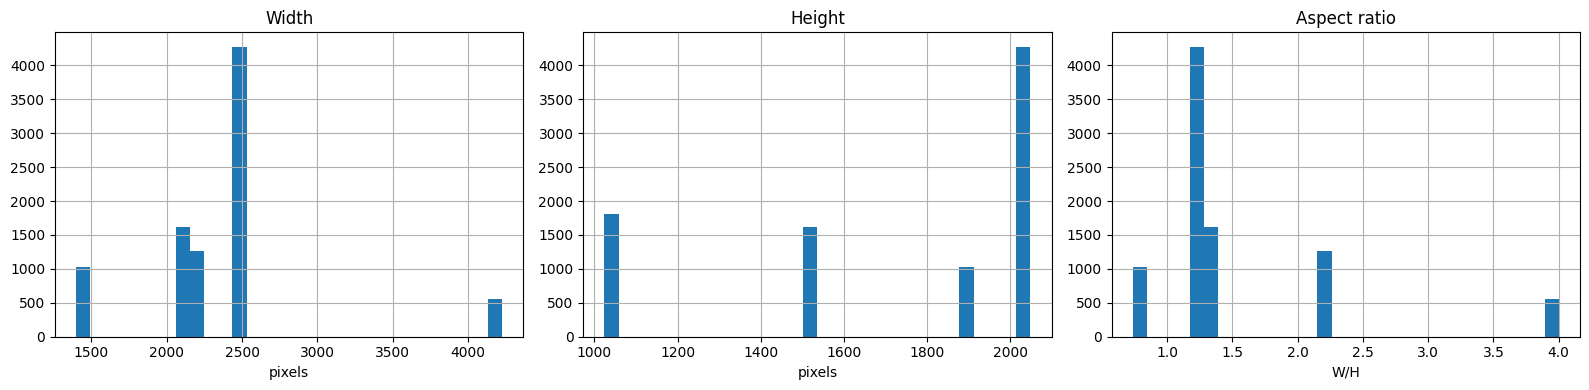

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

image_meta["width"].dropna().hist(bins=30, ax=axes[0])
axes[0].set_title("Width")
axes[0].set_xlabel("pixels")

image_meta["height"].dropna().hist(bins=30, ax=axes[1])
axes[1].set_title("Height")
axes[1].set_xlabel("pixels")

image_meta["aspect_ratio"].dropna().hist(bins=30, ax=axes[2])
axes[2].set_title("Aspect ratio")
axes[2].set_xlabel("W/H")

plt.tight_layout()
plt.show()

## 6. Số lượng ảnh theo category/split

split,test_private,test_private_mixed,test_public,train,validation
category,,,,,
can,321,321,162,412,46
fabric,314,314,156,387,43
fruit_jelly,510,510,160,366,74
rice,277,277,132,313,35
sheet_metal,142,142,114,137,19
vial,276,276,140,291,41
wallplugs,232,232,150,293,33
walnuts,228,228,150,432,48


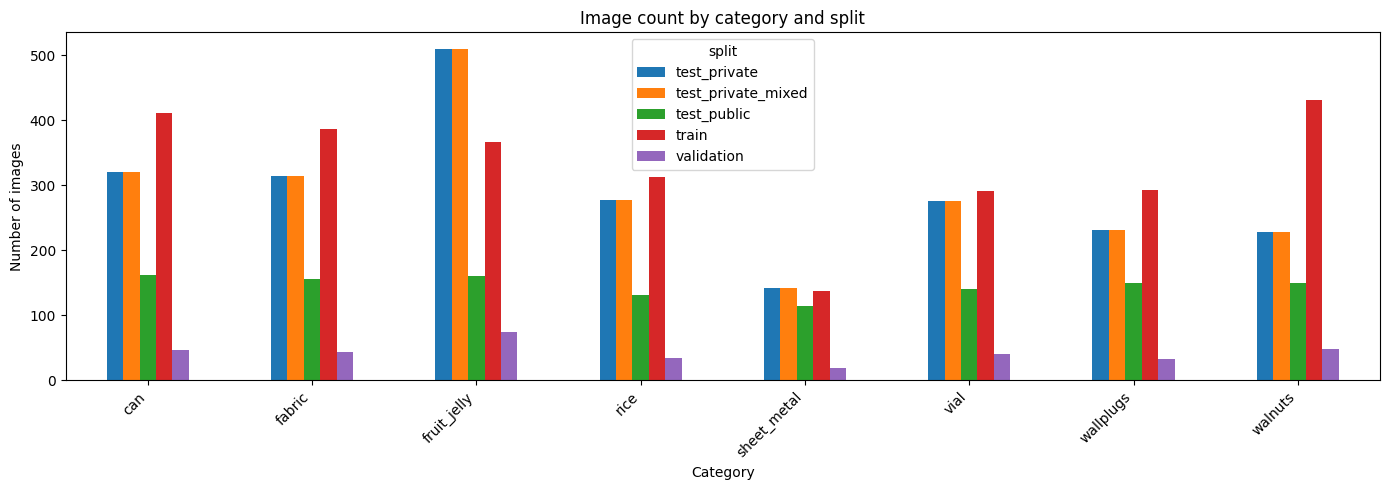

In [ ]:
count_table = (
    image_meta[image_meta["read_ok"]]
    .groupby(["category", "split"])
    .size()
    .unstack(fill_value=0)
)

display(count_table)

ax = count_table.plot(kind="bar", figsize=(14, 5))
ax.set_title("Image count by category and split")
ax.set_ylabel("Number of images")
ax.set_xlabel("Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 7. Subgroup / normal-anomaly path audit

Notebook chỉ dùng nhãn khi path có token rõ như `good`, `normal`, `defect`.  
Không tự gán nhãn cho private split nếu cấu trúc không cho biết.

In [ ]:
status_table = (
    image_meta.groupby(["category", "split", "status_hint"])
    .size()
    .rename("n")
    .reset_index()
)
display(status_table)

subgroup_table = (
    image_meta.groupby(["category", "split", "subgroup"])
    .size()
    .rename("n")
    .reset_index()
    .sort_values(["category", "split", "n"], ascending=[True, True, False])
)
display(subgroup_table.head(120))
subgroup_table.to_csv(OUTPUT_DIR / "subgroup_counts.csv", index=False)

,category,split,status_hint,n
0,can,test_private,unknown,321
1,can,test_private_mixed,unknown,321
2,can,test_public,anomaly,90
3,can,test_public,normal,72
4,can,train,normal,412
5,can,validation,normal,46
6,fabric,test_private,unknown,314
7,fabric,test_private_mixed,unknown,314
8,fabric,test_public,anomaly,90
9,fabric,test_public,normal,66


,category,split,subgroup,n
0,can,test_private,,321
1,can,test_private_mixed,,321
2,can,test_public,bad,90
3,can,test_public,good,72
4,can,train,good,412
5,can,validation,good,46
6,fabric,test_private,,314
7,fabric,test_private_mixed,,314
8,fabric,test_public,bad,90
9,fabric,test_public,good,66


## 8. Visual audit ảnh ngẫu nhiên

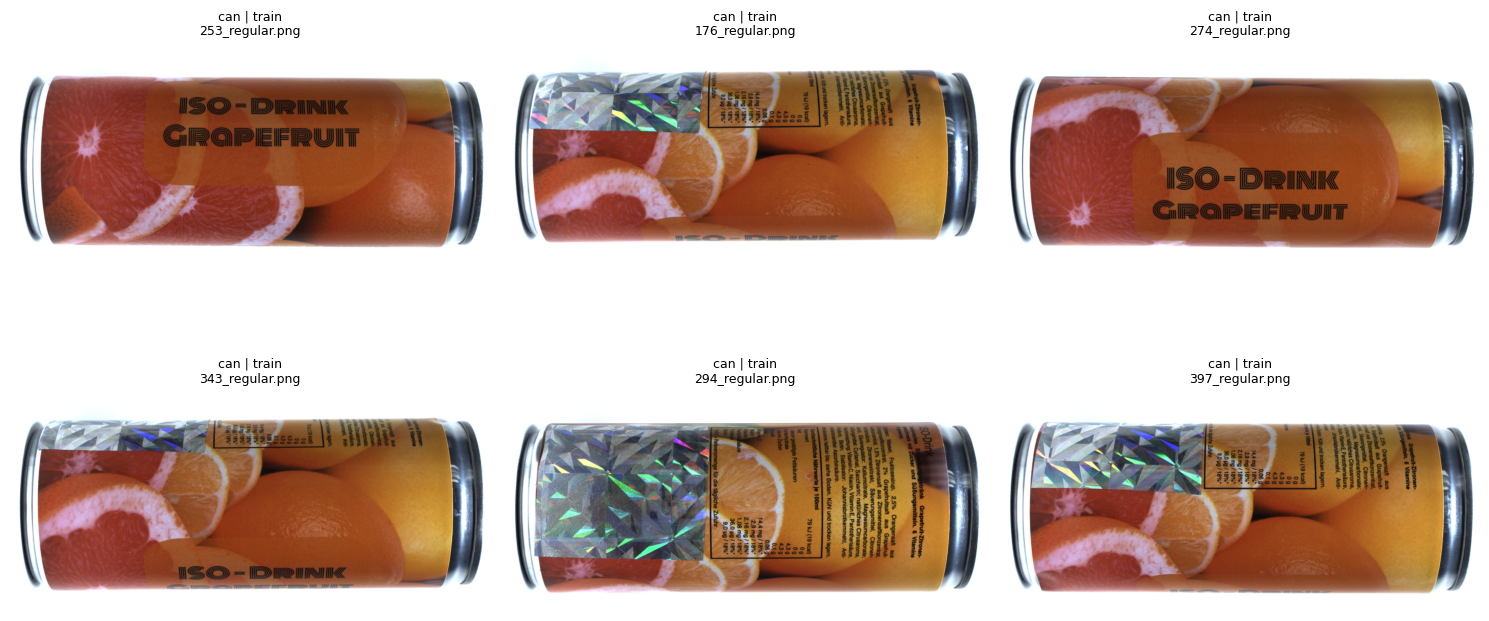

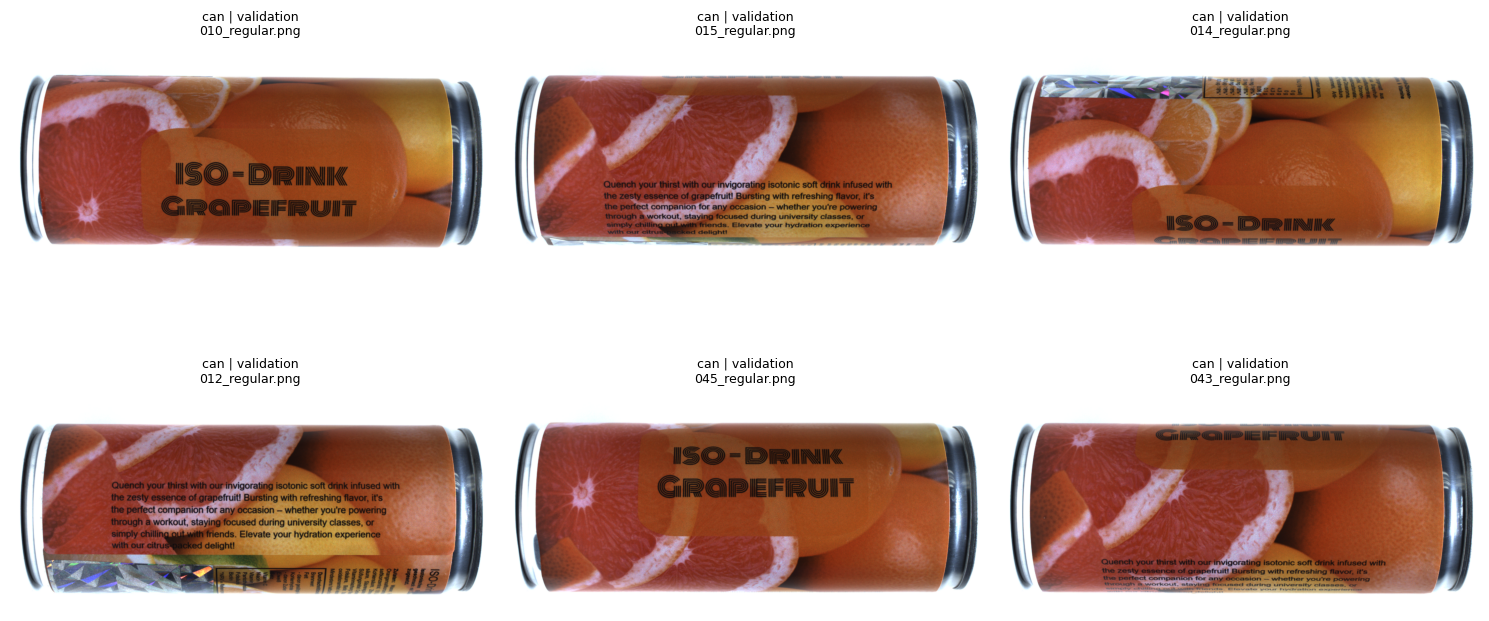

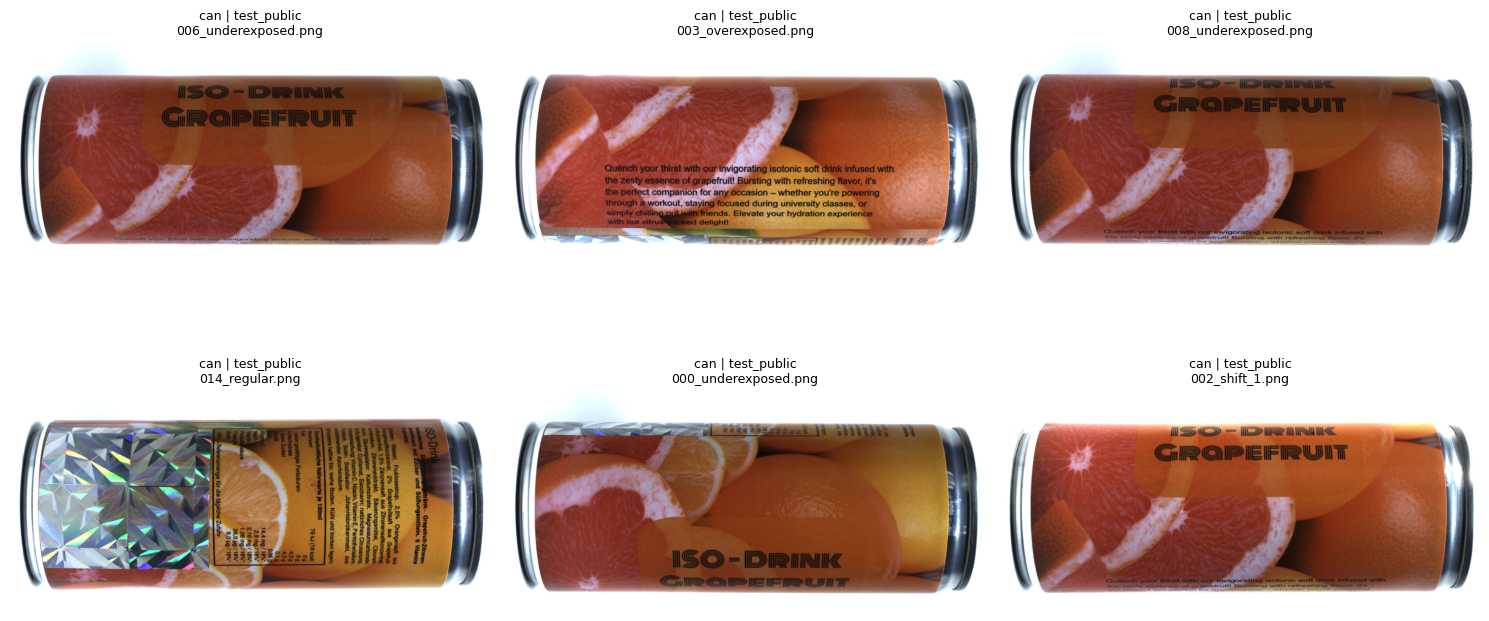

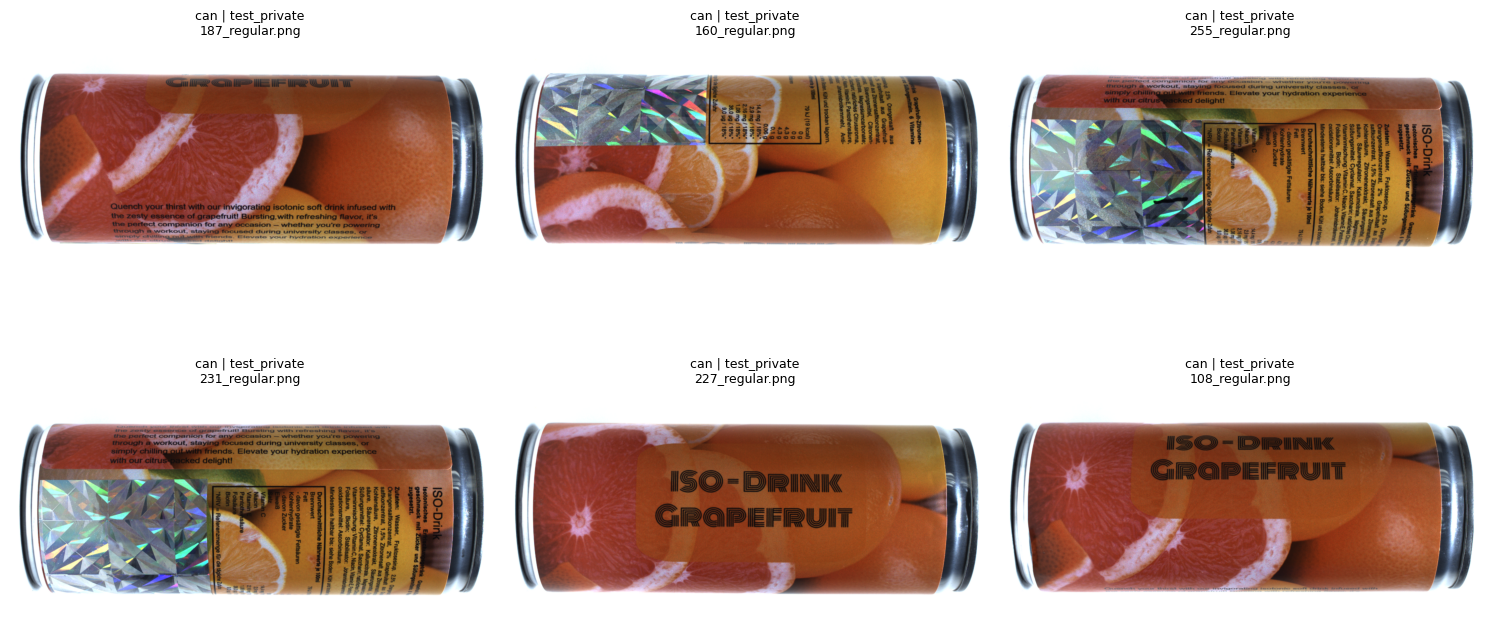

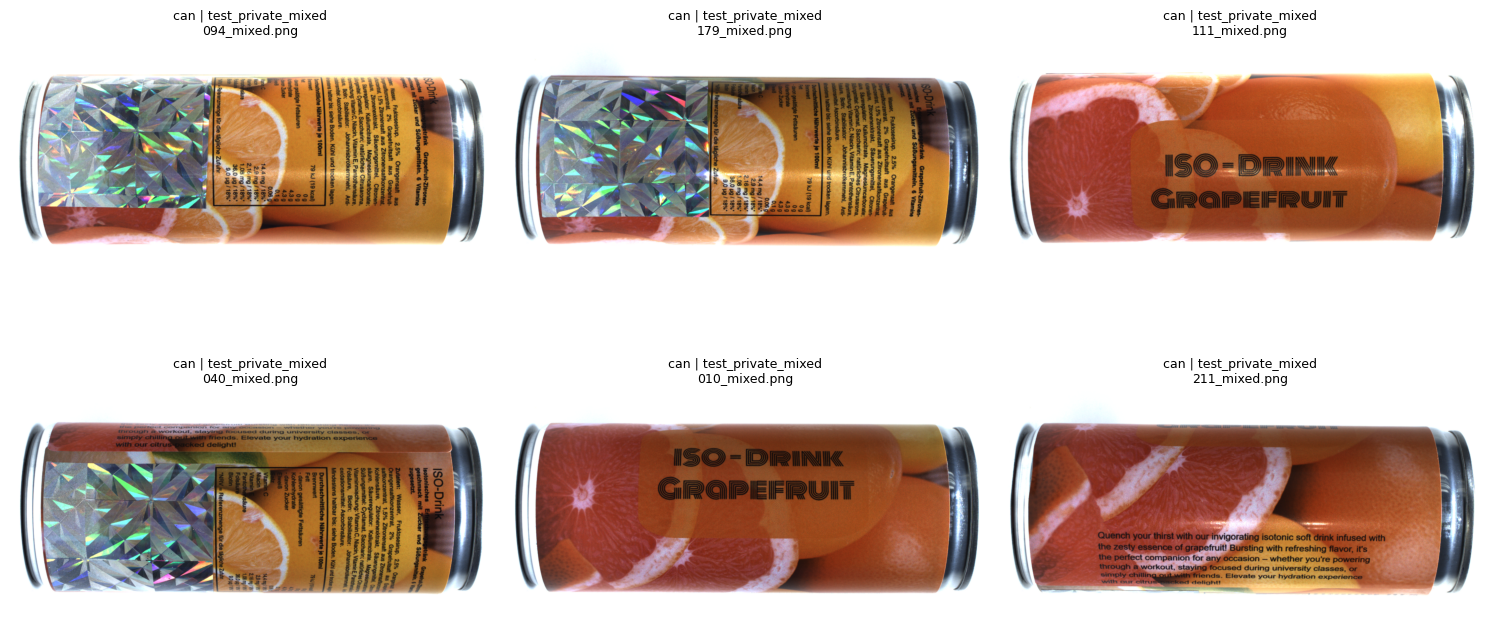

In [ ]:
def show_samples(df, category, split, n=6):
    sub = df[
        (df["category"] == category) &
        (df["split"] == split) &
        df["read_ok"]
    ]

    if len(sub) == 0:
        print("No images:", category, split)
        return

    sample = sub.sample(min(n, len(sub)), random_state=SEED)
    cols = 3
    rows = math.ceil(len(sample) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, (_, r) in zip(axes, sample.iterrows()):
        with Image.open(r["path"]) as im:
            ax.imshow(im.convert("RGB"))
        ax.set_title(f"{category} | {split}\n{r['filename']}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

if categories:
    demo_category = categories[0]
    for sp in EXPECTED_SPLITS:
        if ((image_meta["category"] == demo_category) & (image_meta["split"] == sp)).any():
            show_samples(image_meta, demo_category, sp)

## 9. Exact duplicate / checksum audit

Bật `RUN_FULL_HASH_AUDIT=True` nếu muốn chạy đầy đủ.  
Mục đích là kiểm tra data integrity và tạo checksum; không tự kết luận leakage.

In [ ]:
def file_hash(path, algo="md5", chunk_size=1024 * 1024):
    h = hashlib.new(algo)
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

if RUN_FULL_HASH_AUDIT:
    image_meta[HASH_ALGO] = [
        file_hash(p, HASH_ALGO)
        for p in tqdm(image_meta["path"], desc=f"Computing {HASH_ALGO}")
    ]

    dup = image_meta[image_meta.duplicated(HASH_ALGO, keep=False)].copy()
    cross_split_dup = (
        dup.groupby(HASH_ALGO)
        .filter(lambda g: g["split"].nunique() > 1)
        .sort_values(HASH_ALGO)
    )

    display(cross_split_dup[[
        "category", "split", "rel_path", HASH_ALGO
    ]].head(100))

    image_meta.to_csv(
        OUTPUT_DIR / f"image_metadata_with_{HASH_ALGO}.csv",
        index=False
    )
    cross_split_dup.to_csv(
        OUTPUT_DIR / "exact_duplicates_cross_split.csv",
        index=False
    )
else:
    print("Hash audit is OFF.")

Hash audit is OFF.


# PHẦN II — EDA chuyên sâu cho MS-ILA

Hai câu hỏi dữ liệu nền:

### H1 — Illumination shift có thực sự đáng kể?
Nếu luminance, local shading, clipping hoặc color cast thay đổi rõ giữa train và test, illumination-aware adaptation có cơ sở dữ liệu.

### H2 — Dị vật có tồn tại ở nhiều thang không gian?
Nếu kích thước vùng dị vật phân bố rộng và mask/texture bị mất mạnh khi downsample, multi-scale fusion có cơ sở dữ liệu.

Đây là **EDA evidence**, chưa phải bằng chứng cuối cùng về hiệu quả MS-ILA.

## 10. Lấy mẫu cân bằng cho pixel-level EDA

In [ ]:
def stratified_sample(df, n_per_group=None, group_cols=("category", "split"), seed=SEED):
    if n_per_group is None:
        return df.copy()

    chunks = []
    for _, g in df.groupby(list(group_cols), dropna=False):
        chunks.append(g.sample(min(n_per_group, len(g)), random_state=seed))

    return pd.concat(chunks, ignore_index=True) if chunks else df.iloc[0:0].copy()

pixel_sample = stratified_sample(
    image_meta[image_meta["read_ok"]],
    MAX_PIXEL_IMAGES_PER_GROUP
)

advanced_sample = stratified_sample(
    image_meta[image_meta["read_ok"]],
    MAX_ADVANCED_IMAGES_PER_GROUP
)

print(f"Pixel sample   : {len(pixel_sample):,}/{len(image_meta):,}")
print(f"Advanced sample: {len(advanced_sample):,}/{len(image_meta):,}")

display(pixel_sample.groupby(["category", "split"]).size().unstack(fill_value=0))

Pixel sample   : 1,567/8,734
Advanced sample: 480/8,734


split,test_private,test_private_mixed,test_public,train,validation
category,,,,,
can,40,40,40,40,40
fabric,40,40,40,40,40
fruit_jelly,40,40,40,40,40
rice,40,40,40,40,35
sheet_metal,40,40,40,40,19
vial,40,40,40,40,40
wallplugs,40,40,40,40,33
walnuts,40,40,40,40,40


## 11. Illumination descriptors

Mỗi ảnh được mô tả bằng:

- `lum_mean/std/p05/p50/p95`;
- `dynamic_range = P95-P05`;
- dark/bright clipping;
- Lab-L, HSV-V/S;
- RGB channel mean và `color_cast`;
- low-frequency illumination field;
- `illum_uniformity_cv`, `shading_range`, `tile_lum_cv`;
- edge energy, high-frequency residual, Laplacian variance;
- grayscale entropy;
- FFT low-frequency energy ratio.

Đây là các **proxy định lượng** cho thay đổi chiếu sáng, không phải physical illumination model.

In [ ]:
def resize_for_stats(rgb, max_side=768):
    h, w = rgb.shape[:2]
    s = min(1.0, max_side / max(h, w))
    if s < 1:
        rgb = cv2.resize(
            rgb,
            (max(1, int(round(w*s))), max(1, int(round(h*s)))),
            interpolation=cv2.INTER_AREA
        )
    return rgb

def hist_entropy(gray_u8):
    hist = cv2.calcHist([gray_u8], [0], None, [256], [0, 256]).ravel().astype(np.float64)
    p = hist / max(hist.sum(), 1.0)
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())

def tile_means(y, grid=4):
    h, w = y.shape
    ys = np.linspace(0, h, grid + 1, dtype=int)
    xs = np.linspace(0, w, grid + 1, dtype=int)
    vals = []
    for i in range(grid):
        for j in range(grid):
            patch = y[ys[i]:ys[i+1], xs[j]:xs[j+1]]
            if patch.size:
                vals.append(float(patch.mean()))
    return np.asarray(vals, dtype=np.float32)

def fft_low_frequency_ratio(gray_f, radius_frac=0.10):
    x = gray_f.astype(np.float32)
    x = x - x.mean()

    F = np.fft.fftshift(np.fft.fft2(x))
    P = np.abs(F) ** 2

    h, w = P.shape
    cy, cx = h // 2, w // 2
    yy, xx = np.ogrid[:h, :w]
    radius = max(2, int(radius_frac * min(h, w)))
    low_mask = (yy-cy)**2 + (xx-cx)**2 <= radius**2

    return float(P[low_mask].sum() / (P.sum() + 1e-12))

def illumination_descriptors(path):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        return None

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb = resize_for_stats(rgb, 768)
    f = rgb.astype(np.float32) / 255.0

    y = 0.2126*f[...,0] + 0.7152*f[...,1] + 0.0722*f[...,2]
    gray_u8 = np.clip(y*255.0, 0, 255).astype(np.uint8)

    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)

    sigma = max(3.0, min(y.shape) / 20.0)
    low = cv2.GaussianBlur(y, (0, 0), sigmaX=sigma, sigmaY=sigma)
    high = y - low

    gx = cv2.Sobel(y, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(y, cv2.CV_32F, 0, 1, ksize=3)
    grad = np.sqrt(gx*gx + gy*gy)

    rgb_mean = f.reshape(-1, 3).mean(axis=0)
    tm = tile_means(y, grid=4)

    p05, p50, p95 = np.percentile(y, [5, 50, 95])
    low05, low95 = np.percentile(low, [5, 95])

    return {
        "lum_mean": float(y.mean()),
        "lum_std": float(y.std()),
        "lum_p05": float(p05),
        "lum_p50": float(p50),
        "lum_p95": float(p95),
        "dynamic_range": float(p95 - p05),
        "dark_clip": float((y <= 0.02).mean()),
        "bright_clip": float((y >= 0.98).mean()),

        "lab_L_mean": float(lab[...,0].mean() / 255.0),
        "lab_L_std": float(lab[...,0].std() / 255.0),
        "hsv_V_mean": float(hsv[...,2].mean() / 255.0),
        "hsv_S_mean": float(hsv[...,1].mean() / 255.0),

        "rgb_R_mean": float(rgb_mean[0]),
        "rgb_G_mean": float(rgb_mean[1]),
        "rgb_B_mean": float(rgb_mean[2]),
        "color_cast": float(rgb_mean.max() - rgb_mean.min()),

        "illum_uniformity_cv": float(low.std() / (low.mean() + 1e-6)),
        "shading_range": float(low95 - low05),
        "tile_lum_cv": float(tm.std() / (tm.mean() + 1e-6)) if len(tm) else np.nan,

        "edge_energy": float(grad.mean()),
        "hf_residual_std": float(high.std()),
        "laplacian_var": float(cv2.Laplacian(gray_u8, cv2.CV_32F).var()),
        "entropy_gray": hist_entropy(gray_u8),
        "fft_low_ratio": fft_low_frequency_ratio(y),
    }

illum_rows = []
for _, r in tqdm(pixel_sample.iterrows(), total=len(pixel_sample), desc="Illumination EDA"):
    d = illumination_descriptors(r["path"])
    if d is not None:
        illum_rows.append({
            "image_path": r["path"],
            "rel_path": r["rel_path"],
            "category": r["category"],
            "split": r["split"],
            "status_hint": r["status_hint"],
            **d,
        })

illum = pd.DataFrame(illum_rows)
illum.to_csv(OUTPUT_DIR / "illumination_metrics.csv", index=False)

print("Shape:", illum.shape)
display(illum.head())

Illumination EDA:   0%|          | 0/1567 [00:00<?, ?it/s]

Shape: (1567, 29)


,image_path,rel_path,category,split,status_hint,lum_mean,lum_std,lum_p05,lum_p50,lum_p95,dynamic_range,dark_clip,bright_clip,lab_L_mean,lab_L_std,hsv_V_mean,hsv_S_mean,rgb_R_mean,rgb_G_mean,rgb_B_mean,color_cast,illum_uniformity_cv,shading_range,tile_lum_cv,edge_energy,hf_residual_std,laplacian_var,entropy_gray,fft_low_ratio
0,/content/drive/MyDrive/[Q3-4] 2026/[S7] Comput...,can/can/test_private/187_regular.png,can,test_private,unknown,0.544747,0.317365,0.203096,0.403686,1.0,0.796904,0.0,0.286577,0.579709,0.296388,0.679967,0.404049,0.672814,0.513813,0.474541,0.198274,0.467838,0.724759,0.320583,0.160353,0.133032,324.184357,5.947185,0.966784
1,/content/drive/MyDrive/[Q3-4] 2026/[S7] Comput...,can/can/test_private/160_regular.png,can,test_private,unknown,0.594685,0.290813,0.226381,0.501255,1.0,0.773619,0.0,0.285926,0.626829,0.272340,0.707910,0.370700,0.688561,0.575451,0.509777,0.178784,0.380580,0.673649,0.276047,0.184250,0.136647,413.060852,6.196437,0.947201
2,/content/drive/MyDrive/[Q3-4] 2026/[S7] Comput...,can/can/test_private/255_regular.png,can,test_private,unknown,0.589675,0.303616,0.172360,0.494369,1.0,0.827640,0.0,0.286551,0.614785,0.292189,0.668664,0.317506,0.637609,0.581725,0.527247,0.110362,0.401306,0.682466,0.294747,0.251844,0.146990,754.433899,6.328490,0.929661
3,/content/drive/MyDrive/[Q3-4] 2026/[S7] Comput...,can/can/test_private/231_regular.png,can,test_private,unknown,0.586127,0.303146,0.165571,0.485658,1.0,0.834429,0.0,0.280177,0.611800,0.291123,0.667840,0.327581,0.638630,0.576875,0.522560,0.116070,0.406286,0.691981,0.306416,0.248298,0.143750,707.607361,6.350716,0.930973
4,/content/drive/MyDrive/[Q3-4] 2026/[S7] Comput...,can/can/test_private/227_regular.png,can,test_private,unknown,0.527379,0.319675,0.183432,0.355960,1.0,0.816568,0.0,0.280122,0.563160,0.299330,0.667528,0.441667,0.660884,0.496531,0.442106,0.218778,0.501654,0.745301,0.385523,0.136299,0.125738,245.222656,5.828912,0.971316


## 12. Tóm tắt descriptor theo category/split

In [ ]:
ILLUM_CORE = [
    "lum_mean", "lum_std", "dynamic_range",
    "dark_clip", "bright_clip", "color_cast",
    "illum_uniformity_cv", "shading_range",
    "tile_lum_cv", "fft_low_ratio"
]

illum_summary = (
    illum.groupby(["category", "split"])[ILLUM_CORE]
    .agg(["mean", "median", "std", "min", "max"])
    .round(4)
)

display(illum_summary)
illum_summary.to_csv(OUTPUT_DIR / "illumination_summary_by_category_split.csv")

lum_mean                                  \
                                   mean  median     std     min     max   
category    split                                                         
can         test_private         0.5538  0.5414  0.0260  0.5217  0.6137   
            test_private_mixed   0.5796  0.5808  0.0326  0.5103  0.6572   
            test_public          0.5842  0.5885  0.0440  0.5051  0.6525   
            train                0.5680  0.5701  0.0275  0.5229  0.6091   
            validation           0.5671  0.5593  0.0311  0.5264  0.6115   
fabric      test_private         0.4851  0.4876  0.0143  0.4467  0.5112   
            test_private_mixed   0.4928  0.5001  0.0321  0.4226  0.5442   
            test_public          0.4861  0.4853  0.0330  0.4357  0.5646   
            train                0.4835  0.4836  0.0242  0.4330  0.5266   
            validation           0.4834  0.4839  0.0163  0.4505  0.5143   
fruit_jelly test_private         0.8721  0.8644  0.0228  0.8329  0.9286   
            test_private_mixed   0.8754  0.8745  0.0281  0.8310  0.9431   
            test_public          0.8719  0.8739  0.0228  0.8212  0.9211   
            train                0.8857  0.8887  0.0207  0.8456  0.9233   
            validation           0.8840  0.8840  0.0209  0.8397  0.9225   
rice        test_private         0.6001  0.6018  0.0075  0.5827  0.6127   
            test_private_mixed   0.5810  0.5750  0.0487  0.5175  0.6837   
            test_public          0.5810  0.5729  0.0505  0.5174  0.6831   
            train                0.6079  0.6067  0.0051  0.5996  0.6189   
            validation           0.6063  0.6054  0.0051  0.5981  0.6190   
sheet_metal test_private         0.2066  0.2080  0.0143  0.1774  0.2469   
            test_private_mixed   0.2060  0.2029  0.0315  0.1548  0.2743   
            test_public          0.2040  0.2048  0.0280  0.1488  0.2776   
            train                0.2064  0.2062  0.0165  0.1774  0.2572   
            validation           0.2148  0.2108  0.0165  0.1889  0.2515   
vial        test_private         0.8232  0.8250  0.0080  0.8071  0.8326   
            test_private_mixed   0.8240  0.8268  0.0306  0.7245  0.8673   
            test_public          0.8125  0.8219  0.0393  0.7074  0.8664   
            train                0.8265  0.8273  0.0101  0.8070  0.8440   
            validation           0.8249  0.8243  0.0081  0.8102  0.8381   
wallplugs   test_private         0.1831  0.1887  0.0510  0.0538  0.2666   
            test_private_mixed   0.1639  0.1566  0.0507  0.0415  0.2749   
            test_public          0.1614  0.1606  0.0428  0.0707  0.2536   
            train                0.2002  0.2016  0.0421  0.1236  0.2920   
            validation           0.2001  0.2047  0.0462  0.0926  0.2859   
walnuts     test_private         0.1912  0.1857  0.0383  0.1337  0.2719   
            test_private_mixed   0.1861  0.1876  0.0468  0.1111  0.2760   
            test_public          0.1841  0.1872  0.0411  0.1105  0.2726   
            train                0.1921  0.1939  0.0372  0.1261  0.2681   
            validation           0.1812  0.1751  0.0387  0.1154  0.2909   

                               lum_std                                  \
                                  mean  median     std     min     max   
category    split                                                        
can         test_private        0.3125  0.3156  0.0095  0.2908  0.3232   
            test_private_mixed  0.3054  0.3058  0.0121  0.2740  0.3289   
            test_public         0.3032  0.3033  0.0157  0.2788  0.3313   
            train               0.3072  0.3127  0.0118  0.2881  0.3224   
            validation          0.3078  0.3131  0.0118  0.2893  0.3223   
fabric      test_private        0.1897  0.1908  0.0118  0.1650  0.2110   
            test_private_mixed  0.1868  0.1861  0.0159  0.1594  0.2129   
            test_public         0.1928  0.1935  0.0220  0.1512  0

## 13. Boxplot illumination theo split

Nên xem **theo từng category**, vì vật liệu/camera khác nhau có thể có mức sáng nền khác nhau.

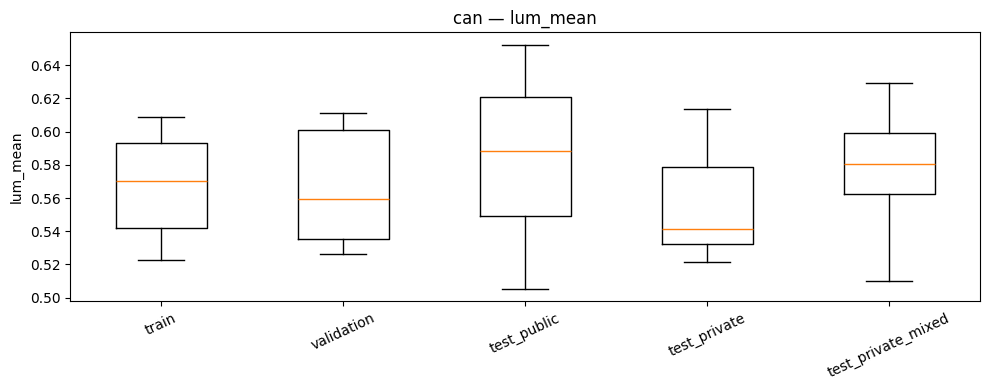

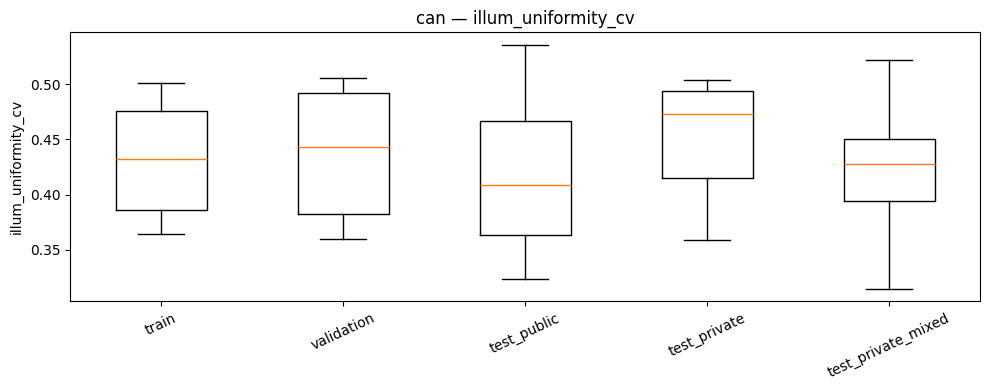

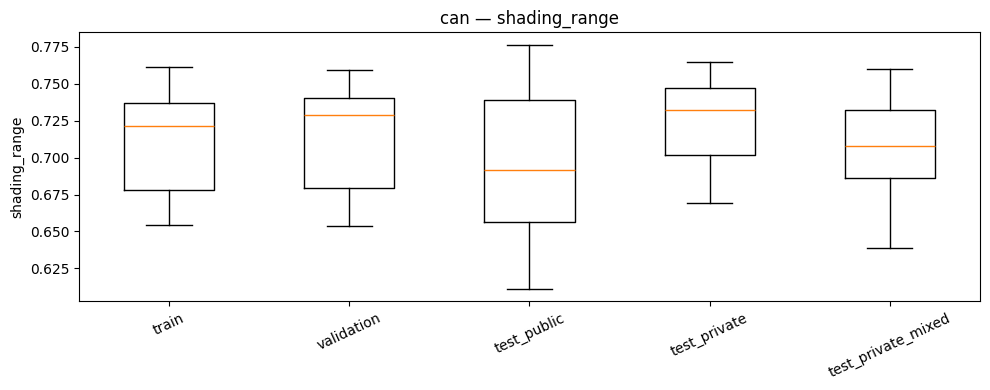

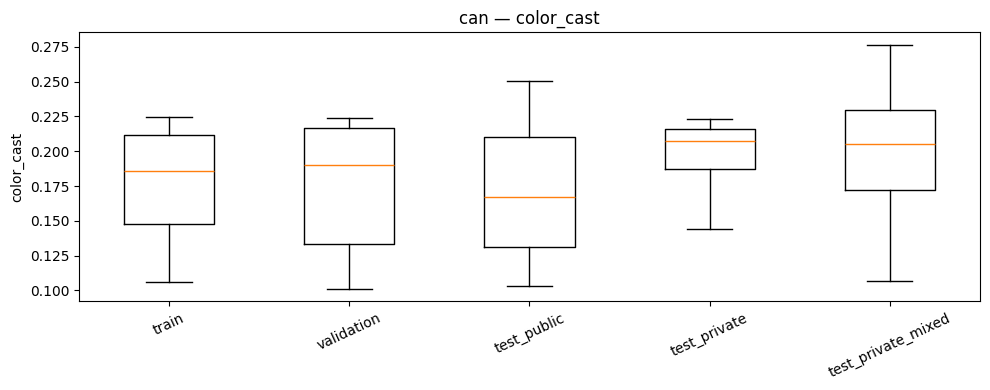

In [ ]:
def plot_metric_by_split(df, metric, category):
    d = df[df["category"] == category]
    order = [s for s in EXPECTED_SPLITS if s in d["split"].unique()]

    vals, labels = [], []
    for s in order:
        v = d.loc[d["split"] == s, metric].dropna().values
        if len(v):
            vals.append(v)
            labels.append(s)

    if not vals:
        return

    plt.figure(figsize=(10, 4))
    plt.boxplot(vals, labels=labels, showfliers=False)
    plt.title(f"{category} — {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

if categories:
    demo_category = categories[0]
    for metric in ["lum_mean", "illum_uniformity_cv", "shading_range", "color_cast"]:
        plot_metric_by_split(illum, metric, demo_category)

## 14. Train → target illumination shift

Với mỗi descriptor \(x\):

\[
D_\text{norm} =
\frac{W_1(P_\text{train},P_\text{target})}
{\sigma_\text{train}+\epsilon}
\]

`illum_shift_score` = trung bình normalized Wasserstein-1 trên nhóm descriptor.

Đây là **EDA score nội bộ**, không phải metric chính thức của MVTec AD 2.

In [ ]:
SHIFT_METRICS = [
    "lum_mean", "lum_std", "dynamic_range",
    "dark_clip", "bright_clip", "color_cast",
    "illum_uniformity_cv", "shading_range",
    "tile_lum_cv", "fft_low_ratio"
]

shift_rows = []

for category in sorted(illum["category"].unique()):
    train = illum[
        (illum["category"] == category) &
        (illum["split"] == "train")
    ]

    if len(train) < 3:
        continue

    for target_split in EXPECTED_SPLITS[1:]:
        tgt = illum[
            (illum["category"] == category) &
            (illum["split"] == target_split)
        ]

        if len(tgt) < 3:
            continue

        metric_scores = {}
        for metric in SHIFT_METRICS:
            a = train[metric].dropna().values
            b = tgt[metric].dropna().values

            if len(a) < 2 or len(b) < 2:
                score = np.nan
            else:
                score = wasserstein_distance(a, b) / (np.std(a) + 1e-6)

            metric_scores[metric] = score

        valid = [v for v in metric_scores.values() if np.isfinite(v)]

        shift_rows.append({
            "category": category,
            "target_split": target_split,
            "illum_shift_score": float(np.mean(valid)) if valid else np.nan,
            **{f"shift_{k}": v for k, v in metric_scores.items()}
        })

illum_shift = pd.DataFrame(shift_rows)
illum_shift.to_csv(OUTPUT_DIR / "illumination_shift.csv", index=False)

if len(illum_shift):
    display(
        illum_shift[["category", "target_split", "illum_shift_score"]]
        .sort_values("illum_shift_score", ascending=False)
    )

,category,target_split,illum_shift_score
25,wallplugs,test_public,55.310837
27,wallplugs,test_private_mixed,43.968684
15,rice,test_private_mixed,4.159569
13,rice,test_public,4.041588
21,vial,test_public,2.924071
23,vial,test_private_mixed,2.403981
31,walnuts,test_private_mixed,1.822264
29,walnuts,test_public,1.743730
17,sheet_metal,test_public,1.532777
19,sheet_metal,test_private_mixed,1.175507


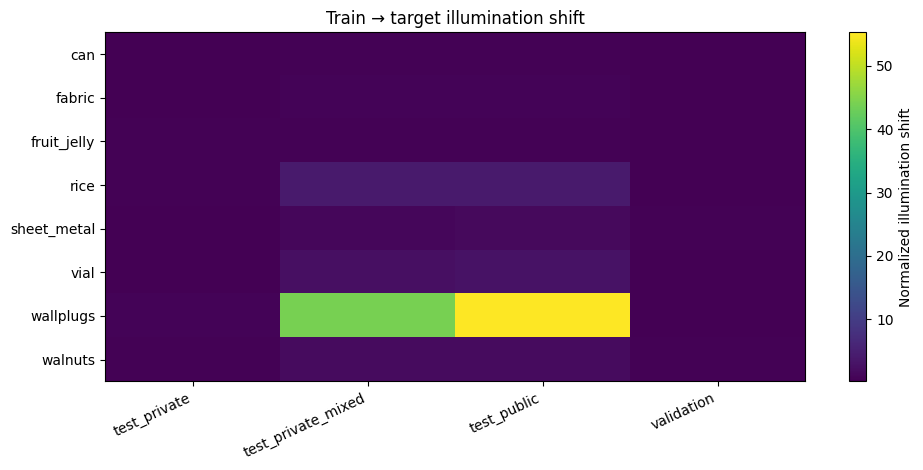

target_split,test_private,test_private_mixed,test_public,validation
category,,,,
can,0.339,0.417,0.572,0.163
fabric,0.245,0.603,0.797,0.209
fruit_jelly,0.455,0.494,0.433,0.163
rice,0.512,4.160,4.042,0.333
sheet_metal,0.245,1.176,1.533,0.402
vial,0.228,2.404,2.924,0.227
wallplugs,0.738,43.969,55.311,0.165
walnuts,0.465,1.822,1.744,0.448


In [ ]:
if len(illum_shift):
    pivot = illum_shift.pivot(
        index="category",
        columns="target_split",
        values="illum_shift_score"
    )

    plt.figure(figsize=(10, max(4, 0.6*len(pivot))))
    im = plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(im, label="Normalized illumination shift")
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=25, ha="right")
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.title("Train → target illumination shift")
    plt.tight_layout()
    plt.show()

    display(pivot.round(3))

## 15. Jensen-Shannon divergence của histogram luminance

Đo thêm sự khác nhau về **hình dạng phân bố mức sáng**, không chỉ mean/variance.

In [ ]:
def aggregate_luminance_hist(df, bins=64):
    hist = np.zeros(bins, dtype=np.float64)

    for p in df["path"]:
        bgr = cv2.imread(str(p), cv2.IMREAD_COLOR)
        if bgr is None:
            continue

        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        rgb = resize_for_stats(rgb, 512)
        f = rgb.astype(np.float32) / 255.0
        y = 0.2126*f[...,0] + 0.7152*f[...,1] + 0.0722*f[...,2]

        h, _ = np.histogram(y, bins=bins, range=(0, 1))
        hist += h

    return hist / max(hist.sum(), 1.0)

hist_cache = {}
js_rows = []

for category in categories:
    for split in EXPECTED_SPLITS:
        d = pixel_sample[
            (pixel_sample["category"] == category) &
            (pixel_sample["split"] == split)
        ]
        if len(d):
            hist_cache[(category, split)] = aggregate_luminance_hist(d)

    train_h = hist_cache.get((category, "train"))
    if train_h is None:
        continue

    for target_split in EXPECTED_SPLITS[1:]:
        h = hist_cache.get((category, target_split))
        if h is None:
            continue

        js = float(jensenshannon(train_h + 1e-12, h + 1e-12) ** 2)

        js_rows.append({
            "category": category,
            "target_split": target_split,
            "luminance_js_divergence": js,
        })

luminance_js = pd.DataFrame(js_rows)
luminance_js.to_csv(OUTPUT_DIR / "luminance_histogram_js.csv", index=False)

if len(luminance_js):
    display(
        luminance_js.sort_values("luminance_js_divergence", ascending=False)
    )

,category,target_split,luminance_js_divergence
25,wallplugs,test_public,0.076558
27,wallplugs,test_private_mixed,0.049956
13,rice,test_public,0.017751
29,walnuts,test_public,0.017543
15,rice,test_private_mixed,0.016360
31,walnuts,test_private_mixed,0.010856
17,sheet_metal,test_public,0.007289
21,vial,test_public,0.005990
19,sheet_metal,test_private_mixed,0.004276
28,walnuts,validation,0.003600


## 16. Phân rã trực quan: RGB → luminance → low-frequency shading → high-frequency residual

fruit_jelly train fruit_jelly/train/good/079_regular.png


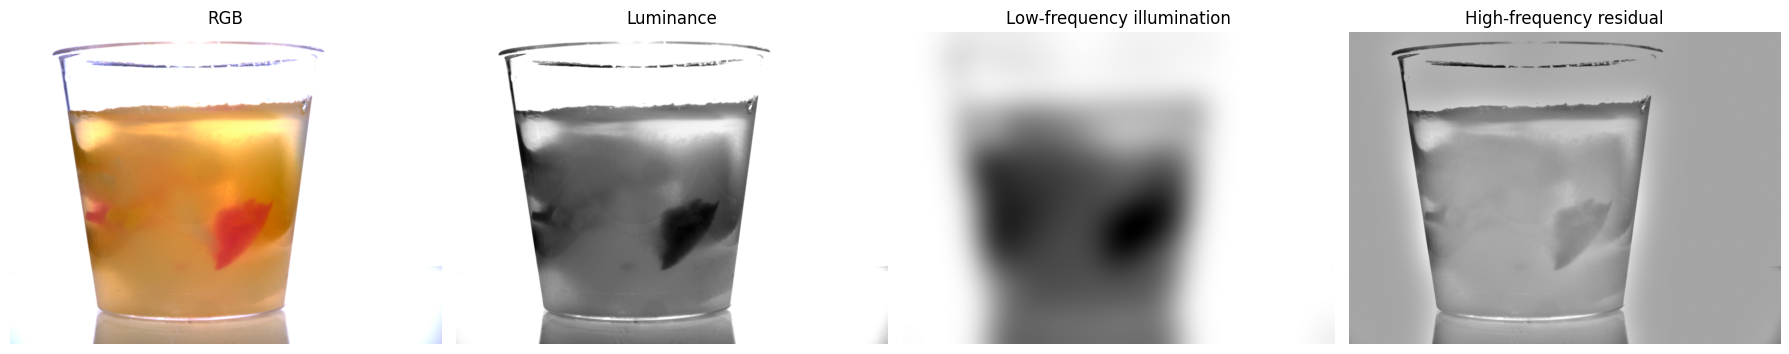

In [ ]:
def show_illumination_decomposition(path):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb = resize_for_stats(rgb, 1024)

    f = rgb.astype(np.float32) / 255.0
    y = 0.2126*f[...,0] + 0.7152*f[...,1] + 0.0722*f[...,2]

    sigma = max(3.0, min(y.shape) / 20.0)
    low = cv2.GaussianBlur(y, (0, 0), sigmaX=sigma, sigmaY=sigma)
    high = y - low

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    axes[0].imshow(rgb)
    axes[0].set_title("RGB")
    axes[1].imshow(y, cmap="gray")
    axes[1].set_title("Luminance")
    axes[2].imshow(low, cmap="gray")
    axes[2].set_title("Low-frequency illumination")
    axes[3].imshow(high, cmap="gray")
    axes[3].set_title("High-frequency residual")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

if len(pixel_sample):
    demo = pixel_sample.sample(1, random_state=SEED).iloc[0]
    print(demo["category"], demo["split"], demo["rel_path"])
    show_illumination_decomposition(demo["path"])

# PHẦN III — Mask và hình học dị vật

Phần này chỉ hữu ích nếu scanner phát hiện mask.

Pairing dùng heuristic, vì vậy luôn xem **pairing rate** và kiểm tra bằng mắt trước khi dùng số liệu cho paper.

## 17. Image-mask pairing heuristic

In [ ]:
def canonical_stem(stem):
    s = normalize_token(stem)
    for suffix in ["_mask", "_gt", "_label", "_seg", "_segmentation"]:
        if s.endswith(suffix):
            s = s[:-len(suffix)]
    return s

mask_index = defaultdict(list)

for _, m in masks_manifest.iterrows():
    key = (m["category"], m["split"], canonical_stem(m["stem"]))
    mask_index[key].append(m["path"])

pair_rows = []

for _, im in image_meta[image_meta["read_ok"]].iterrows():
    key = (im["category"], im["split"], canonical_stem(im["stem"]))
    candidates = mask_index.get(key, [])

    if not candidates and len(masks_manifest):
        temp = masks_manifest[
            (masks_manifest["category"] == im["category"]) &
            (masks_manifest["stem"].map(canonical_stem) == canonical_stem(im["stem"]))
        ]
        candidates = temp["path"].tolist()

    pair_rows.append({
        "image_path": im["path"],
        "image_rel_path": im["rel_path"],
        "category": im["category"],
        "split": im["split"],
        "mask_path": candidates[0] if candidates else None,
        "n_mask_candidates": len(candidates),
    })

mask_pairs = pd.DataFrame(pair_rows)
mask_pairs["paired"] = mask_pairs["mask_path"].notna()
mask_pairs.to_csv(OUTPUT_DIR / "image_mask_pairs.csv", index=False)

print("Overall pairing rate:", f"{mask_pairs['paired'].mean():.2%}")

display(
    mask_pairs.groupby(["category", "split"])["paired"]
    .agg(["count", "sum", "mean"])
    .round(3)
)

Overall pairing rate: 17.96%


count  sum   mean
category    split                                
can         test_private          321   15  0.047
            test_private_mixed    321    0  0.000
            test_public           162  162  1.000
            train                 412   15  0.036
            validation             46   15  0.326
fabric      test_private          314   15  0.048
            test_private_mixed    314    0  0.000
            test_public           156  156  1.000
            train                 387   15  0.039
            validation             43   15  0.349
fruit_jelly test_private          510   30  0.059
            test_private_mixed    510    0  0.000
            test_public           160  160  1.000
            train                 366   30  0.082
            validation             74   30  0.405
rice        test_private          277   15  0.054
            test_private_mixed    277    0  0.000
            test_public           132  132  1.000
            train                 313   15  0.048
            validation             35   15  0.429
sheet_metal test_private          142   15  0.106
            test_private_mixed    142    0  0.000
            test_public           114  114  1.000
            train                 137   15  0.109
            validation             19   15  0.789
vial        test_private          276   15  0.054
            test_private_mixed    276    0  0.000
            test_public           140  140  1.000
            train                 291   15  0.052
            validation             41   15  0.366
wallplugs   test_private          232   15  0.065
            test_private_mixed    232    0  0.000
            test_public           150  150  1.000
            train                 293   15  0.051
            validation             33   15  0.455
walnuts     test_private          228   15  0.066
            test_private_mixed    228    0  0.000
            test_public           150  150  1.000
            train                 432   15  0.035
            validation             48   15  0.312

## 18. Defect geometry

Tính:
- mask area ratio;
- bbox width/height;
- min/max bbox side;
- connected components;
- perimeter/area proxy nếu có `scikit-image`.

In [ ]:
def load_binary_mask(path, target_hw=None):
    m = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if m is None:
        return None

    if target_hw is not None and m.shape[:2] != target_hw:
        m = cv2.resize(
            m,
            (target_hw[1], target_hw[0]),
            interpolation=cv2.INTER_NEAREST
        )

    return (m > 0).astype(np.uint8)

def mask_geometry(mask):
    h, w = mask.shape
    area = int(mask.sum())

    if area == 0:
        return {
            "mask_area_px": 0,
            "mask_area_ratio": 0.0,
            "n_components": 0,
            "bbox_w_px": 0,
            "bbox_h_px": 0,
            "bbox_w_ratio": 0.0,
            "bbox_h_ratio": 0.0,
            "bbox_min_side_px": 0,
            "bbox_max_side_px": 0,
            "perimeter_area_ratio": np.nan,
        }

    ys, xs = np.where(mask > 0)
    bw = int(xs.max() - xs.min() + 1)
    bh = int(ys.max() - ys.min() + 1)

    ncc, _ = cv2.connectedComponents(mask.astype(np.uint8))
    n_components = max(0, ncc - 1)

    par = np.nan
    if SKIMAGE_OK:
        lab = sk_label(mask > 0)
        props = regionprops(lab)
        perimeter = sum(float(p.perimeter) for p in props)
        par = perimeter / (area + 1e-6)

    return {
        "mask_area_px": area,
        "mask_area_ratio": area / (h*w),
        "n_components": n_components,
        "bbox_w_px": bw,
        "bbox_h_px": bh,
        "bbox_w_ratio": bw / w,
        "bbox_h_ratio": bh / h,
        "bbox_min_side_px": min(bw, bh),
        "bbox_max_side_px": max(bw, bh),
        "perimeter_area_ratio": par,
    }

geometry_rows = []

paired_df = mask_pairs[mask_pairs["paired"]]

for _, r in tqdm(paired_df.iterrows(), total=len(paired_df), desc="Mask geometry"):
    bgr = cv2.imread(str(r["image_path"]), cv2.IMREAD_COLOR)
    if bgr is None:
        continue

    h, w = bgr.shape[:2]
    m = load_binary_mask(r["mask_path"], (h, w))
    if m is None:
        continue

    geometry_rows.append({
        **r.to_dict(),
        **mask_geometry(m),
    })

defect_geometry = pd.DataFrame(geometry_rows)
defect_geometry.to_csv(OUTPUT_DIR / "defect_geometry.csv", index=False)

print("Masks analyzed:", len(defect_geometry))

if len(defect_geometry):
    display(
        defect_geometry.groupby(["category", "split"])[
            ["mask_area_ratio", "bbox_min_side_px", "bbox_max_side_px", "n_components"]
        ].agg(["count", "median", "mean", "min", "max"]).round(4)
    )

Mask geometry:   0%|          | 0/1569 [00:00<?, ?it/s]

Masks analyzed: 1569


mask_area_ratio                                  \
                                   count  median    mean     min     max   
category    split                                                          
can         test_private              15  0.0001  0.0001  0.0000  0.0002   
            test_public              162  0.0001  0.0001  0.0000  0.0002   
            train                     15  0.0001  0.0001  0.0000  0.0002   
            validation                15  0.0001  0.0001  0.0000  0.0002   
fabric      test_private              15  0.0001  0.0125  0.0000  0.1837   
            test_public              156  0.0001  0.0144  0.0000  0.1837   
            train                     15  0.0001  0.0125  0.0000  0.1837   
            validation                15  0.0001  0.0125  0.0000  0.1837   
fruit_jelly test_private              30  0.0040  0.0134  0.0002  0.0580   
            test_public              160  0.0040  0.0152  0.0002  0.0580   
            train                     30  0.0040  0.0134  0.0002  0.0580   
            validation                30  0.0040  0.0134  0.0002  0.0580   
rice        test_private              15  0.0011  0.0026  0.0005  0.0135   
            test_public              132  0.0011  0.0031  0.0005  0.0135   
            train                     15  0.0011  0.0026  0.0005  0.0135   
            validation                15  0.0011  0.0026  0.0005  0.0135   
sheet_metal test_private              15  0.0025  0.0058  0.0001  0.0411   
            test_public              114  0.0026  0.0052  0.0001  0.0411   
            train                     15  0.0025  0.0058  0.0001  0.0411   
            validation                15  0.0025  0.0058  0.0001  0.0411   
vial        test_private              15  0.0107  0.0283  0.0021  0.1297   
            test_public              140  0.0097  0.0237  0.0021  0.1297   
            train                     15  0.0107  0.0283  0.0021  0.1297   
            validation                15  0.0107  0.0283  0.0021  0.1297   
wallplugs   test_private              15  0.0004  0.0027  0.0000  0.0147   
            test_public              150  0.0004  0.0020  0.0000  0.0147   
            train                     15  0.0004  0.0027  0.0000  0.0147   
            validation                15  0.0004  0.0027  0.0000  0.0147   
walnuts     test_private              15  0.0122  0.0183  0.0002  0.0615   
            test_public              150  0.0122  0.0191  0.0002  0.0615   
            train                     15  0.0122  0.0183  0.0002  0.0615   
            validation                15  0.0122  0.0183  0.0002  0.0615   

                         bbox_min_side_px                               \
                                    count  median      mean  min   max   
category    split                                                        
can         test_private               15    10.0   11.6667    5    31   
            test_public               162    10.0   11.6667    5    31   
            train                      15    10.0   11.6667    5    31   
            validation                 15    10.0   11.6667    5    31   
fabric      test_private               15    51.0  365.8000   20  1623   
            test_public               156    71.0  386.2308   20  1623   
            train                      15    51.0  365.8000   20  1623   
            validation                 15    51.0  365.8000   20  1623   
fruit_jelly test_private               30   336.0  393.5333  127   770   
            test_public               160   330.0  369.4500  127   770   
            train                      30   336.0  393.5333  127   770   
            validation                 30   336.0  393.5333  127   770   
rice        test_private               15    77.0  179.7333   58   888   
            test_public               132    77.0  167.5455   58   888   
            train                      15    77.0  179.7333   58   888   
            validation          

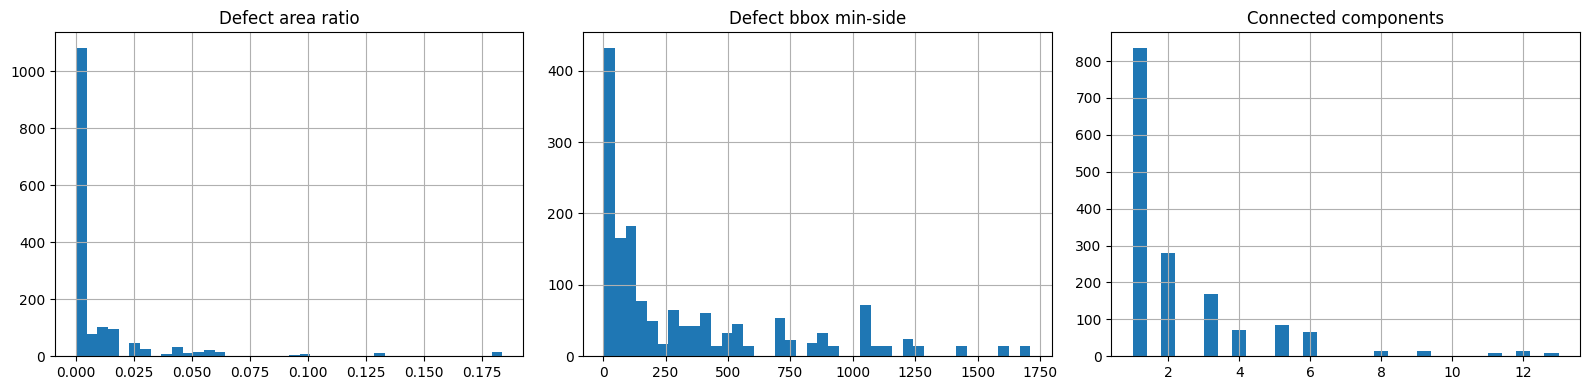

In [ ]:
if len(defect_geometry):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    defect_geometry["mask_area_ratio"].clip(lower=1e-8).hist(bins=40, ax=axes[0])
    axes[0].set_title("Defect area ratio")

    defect_geometry["bbox_min_side_px"].hist(bins=40, ax=axes[1])
    axes[1].set_title("Defect bbox min-side")

    defect_geometry["n_components"].hist(bins=30, ax=axes[2])
    axes[2].set_title("Connected components")

    plt.tight_layout()
    plt.show()

## 19. Mask survival tại các scale MS-ILA

Mask được downsample rồi upsample về kích thước gốc.

Đo:
- `mask_survival_iou`;
- `area_retention`;
- `component_retention`.

Nếu defect nhỏ mất ở scale thấp, fine-scale branch là cần thiết.

In [ ]:
def binary_iou(a, b):
    a = a > 0
    b = b > 0
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter / union) if union else 1.0

def count_components(mask):
    ncc, _ = cv2.connectedComponents((mask > 0).astype(np.uint8))
    return max(0, ncc - 1)

survival_rows = []

for _, r in tqdm(defect_geometry.iterrows(), total=len(defect_geometry), desc="Mask scale survival"):
    bgr = cv2.imread(str(r["image_path"]), cv2.IMREAD_COLOR)
    if bgr is None:
        continue

    h, w = bgr.shape[:2]
    m = load_binary_mask(r["mask_path"], (h, w))
    if m is None:
        continue

    area0 = max(int(m.sum()), 1)
    cc0 = max(count_components(m), 1)

    for scale in MSILA_SCALES:
        hs = max(1, int(round(h*scale)))
        ws = max(1, int(round(w*scale)))

        small = cv2.resize(m, (ws, hs), interpolation=cv2.INTER_NEAREST)
        up = cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)
        up = (up > 0).astype(np.uint8)

        survival_rows.append({
            "category": r["category"],
            "split": r["split"],
            "image_path": r["image_path"],
            "mask_area_ratio": r["mask_area_ratio"],
            "bbox_min_side_px": r["bbox_min_side_px"],
            "scale": scale,
            "mask_survival_iou": binary_iou(m, up),
            "area_retention": float(up.sum() / area0),
            "component_retention": float(count_components(up) / cc0),
        })

mask_survival = pd.DataFrame(survival_rows)
mask_survival.to_csv(OUTPUT_DIR / "multiscale_mask_survival.csv", index=False)

if len(mask_survival):
    display(
        mask_survival.groupby("scale")[
            ["mask_survival_iou", "area_retention", "component_retention"]
        ].agg(["mean", "median", "std"]).round(4)
    )

Mask scale survival:   0%|          | 0/1569 [00:00<?, ?it/s]

mask_survival_iou                 area_retention                  \
                   mean  median     std           mean  median     std   
scale                                                                    
0.3              0.7345  0.8405  0.2377         1.0013  0.9999  0.0571   
0.4              0.7752  0.8740  0.2153         0.9894  0.9995  0.0620   
0.5              0.9032  0.9512  0.1041         1.0007  1.0000  0.0223   
0.6              0.8134  0.8966  0.1828         1.0040  1.0003  0.0331   
0.7              0.8203  0.8990  0.1787         0.9999  0.9999  0.0259   

      component_retention                 
                     mean median     std  
scale                                     
0.3                1.3891    1.0  1.1022  
0.4                1.3162    1.0  1.0021  
0.5                1.1653    1.0  0.7206  
0.6                1.1663    1.0  0.6495  
0.7                1.1324    1.0  0.6540

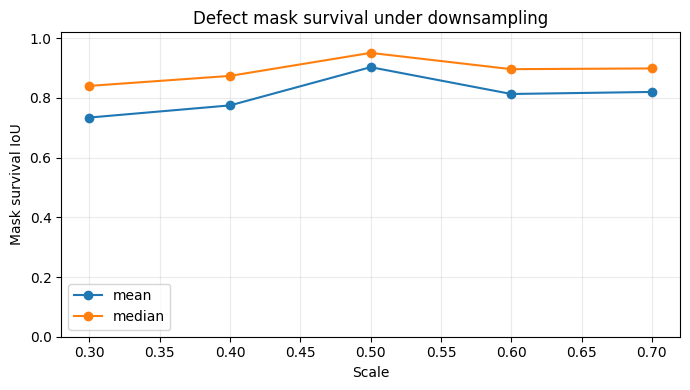

In [ ]:
if len(mask_survival):
    s = mask_survival.groupby("scale")["mask_survival_iou"].agg(["mean", "median"])

    plt.figure(figsize=(7, 4))
    plt.plot(s.index, s["mean"], marker="o", label="mean")
    plt.plot(s.index, s["median"], marker="o", label="median")
    plt.xlabel("Scale")
    plt.ylabel("Mask survival IoU")
    plt.title("Defect mask survival under downsampling")
    plt.ylim(0, 1.02)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

# PHẦN IV — Defect visibility dưới chiếu sáng

Nếu có mask, đo contrast giữa defect và **local background ring**:

\[
C_L =
\frac{|\mu_\text{defect}-\mu_\text{local-bg}|}
{\sigma_\text{local-bg}+\epsilon}
\]

`local_luminance_contrast_z` thấp → defect khó tách khỏi local background về luminance.

Đây là visibility proxy, không phải segmentation score.

## 20. Defect vs local-background contrast

In [ ]:
def dilate_mask(mask, radius):
    radius = max(1, int(radius))
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (2*radius+1, 2*radius+1)
    )
    return cv2.dilate(mask.astype(np.uint8), kernel)

def defect_visibility_metrics(image_path, mask_path):
    bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if bgr is None:
        return None

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    h, w = rgb.shape[:2]
    m = load_binary_mask(mask_path, (h, w))

    if m is None or m.sum() == 0:
        return None

    f = rgb.astype(np.float32) / 255.0
    y = 0.2126*f[...,0] + 0.7152*f[...,1] + 0.0722*f[...,2]

    radius = max(3, int(round(0.02*min(h, w))))
    outer = dilate_mask(m, radius)
    ring = (outer > 0) & (m == 0)

    if ring.sum() < 20:
        ring = (m == 0)

    dv = y[m > 0]
    bv = y[ring]

    if len(dv) == 0 or len(bv) == 0:
        return None

    mu_d = float(dv.mean())
    mu_b = float(bv.mean())
    sd_b = float(bv.std())

    d_rgb = f[m > 0].mean(axis=0)
    b_rgb = f[ring].mean(axis=0)

    return {
        "defect_lum_mean": mu_d,
        "local_bg_lum_mean": mu_b,
        "local_bg_lum_std": sd_b,
        "local_luminance_abs_contrast": abs(mu_d - mu_b),
        "local_luminance_contrast_z": abs(mu_d - mu_b) / (sd_b + 1e-6),
        "local_rgb_mean_distance": float(np.linalg.norm(d_rgb - b_rgb)),
    }

visibility_rows = []

for _, r in tqdm(defect_geometry.iterrows(), total=len(defect_geometry), desc="Defect visibility"):
    v = defect_visibility_metrics(r["image_path"], r["mask_path"])
    if v is None:
        continue

    visibility_rows.append({
        "image_path": r["image_path"],
        "category": r["category"],
        "split": r["split"],
        "mask_area_ratio": r["mask_area_ratio"],
        **v,
    })

defect_visibility = pd.DataFrame(visibility_rows)
defect_visibility.to_csv(OUTPUT_DIR / "defect_visibility.csv", index=False)

if len(defect_visibility):
    display(
        defect_visibility.groupby(["category", "split"])[
            ["local_luminance_abs_contrast",
             "local_luminance_contrast_z",
             "local_rgb_mean_distance"]
        ].agg(["count", "median", "mean", "std"]).round(4)
    )

Defect visibility:   0%|          | 0/1569 [00:00<?, ?it/s]

local_luminance_abs_contrast                          \
                                                count  median    mean     std   
category    split                                                               
can         test_private                           15  0.0117  0.0201  0.0212   
            test_public                           162  0.0819  0.1143  0.0928   
            train                                  15  0.0113  0.0309  0.0423   
            validation                             15  0.0511  0.0618  0.0641   
fabric      test_private                           15  0.0402  0.0540  0.0495   
            test_public                           156  0.1343  0.1539  0.1124   
            train                                  15  0.0420  0.0576  0.0570   
            validation                             15  0.0836  0.0929  0.0819   
fruit_jelly test_private                           30  0.0247  0.0319  0.0257   
            test_public                           160  0.0612  0.1068  0.1034   
            train                                  30  0.0261  0.0285  0.0162   
            validation                             30  0.0122  0.0182  0.0155   
rice        test_private                           15  0.0076  0.0149  0.0157   
            test_public                           132  0.0292  0.0457  0.0483   
            train                                  15  0.0190  0.0255  0.0274   
            validation                             15  0.0196  0.0201  0.0192   
sheet_metal test_private                           15  0.0226  0.0427  0.0579   
            test_public                           114  0.2630  0.2536  0.1751   
            train                                  15  0.0187  0.0225  0.0169   
            validation                             15  0.0141  0.0252  0.0348   
vial        test_private                           15  0.0988  0.1099  0.0875   
            test_public                           140  0.2986  0.2275  0.1582   
            train                                  15  0.0807  0.1142  0.0908   
            validation                             15  0.0716  0.1170  0.1029   
wallplugs   test_private                           15  0.0240  0.0374  0.0432   
            test_public                           150  0.0774  0.1063  0.1119   
            train                                  15  0.0494  0.0700  0.0690   
            validation                             15  0.0398  0.0509  0.0408   
walnuts     test_private                           15  0.0258  0.0264  0.0234   
            test_public                           150  0.0664  0.0829  0.0766   
            train                                  15  0.0283  0.0353  0.0398   
            validation                             15  0.0120  0.0208  0.0216   

                         local_luminance_contrast_z                          \
                                              count  median    mean     std   
category    split                                                             
can         test_private                         15  0.3647  0.3288  0.1861   
            test_public                         162  0.7074  0.9205  0.5688   
            train                                15  0.1997  0.2980  0.2438   
            validation                           15  0.3091  0.4682  0.4398   
fabric      test_private                         15  0.2175  0.3152  0.2453   
            test_public                         156  0.7373  0.9666  0.8346   
            train                                15  0.2783  0.3255  0.3058   
            validation                           15  0.4572  0.5070  0.4185   
fruit_jelly test_private                         30  0.2039  0.2369  0.1680   
            test_public                         160  0.9312  1.2149  1.3612   
            train                                30  0.2818  0.2815  0.1396   
            validation                           30  0.1571  0.1877  0.1504   
rice

## 21. Tương quan illumination ↔ defect visibility

Dùng Spearman correlation.  
Không diễn giải correlation thành quan hệ nhân quả.

In [ ]:
visibility_corr = pd.DataFrame()

if len(defect_visibility) and len(illum):
    vis_illum = defect_visibility.merge(
        illum,
        on=["image_path", "category", "split"],
        how="inner"
    )

    x_metrics = [
        "lum_mean",
        "dynamic_range",
        "dark_clip",
        "bright_clip",
        "illum_uniformity_cv",
        "shading_range",
        "color_cast",
    ]

    rows = []

    for category, g in vis_illum.groupby("category"):
        for x in x_metrics:
            gg = g[[x, "local_luminance_contrast_z"]].dropna()

            if len(gg) >= 8:
                rho, p = spearmanr(
                    gg[x],
                    gg["local_luminance_contrast_z"]
                )

                rows.append({
                    "category": category,
                    "illum_metric": x,
                    "spearman_rho": float(rho),
                    "p_value": float(p),
                    "n": len(gg),
                })

    visibility_corr = pd.DataFrame(rows)

    if len(visibility_corr):
        visibility_corr.to_csv(
            OUTPUT_DIR / "illumination_visibility_correlation.csv",
            index=False
        )

        display(
            visibility_corr.reindex(
                visibility_corr["spearman_rho"].abs().sort_values(ascending=False).index
            ).head(50)
        )
else:
    print("Không đủ mask/illumination pairs.")

,category,illum_metric,spearman_rho,p_value,n
32,sheet_metal,illum_uniformity_cv,0.453322,0.000149,65
36,vial,dynamic_range,-0.448270,0.000328,60
33,sheet_metal,shading_range,0.343007,0.005155,65
8,fabric,dynamic_range,0.311278,0.019533,56
20,fruit_jelly,color_cast,-0.301427,0.013182,67
26,rice,shading_range,0.297838,0.021961,59
10,fabric,bright_clip,0.297812,0.025800,56
22,rice,dynamic_range,0.294448,0.023590,59
25,rice,illum_uniformity_cv,0.258069,0.048447,59
31,sheet_metal,bright_clip,0.243102,0.051021,65


# PHẦN V — Multi-scale information retention không cần mask

Đo mức mất:
- edge;
- high-frequency texture;
- SSIM sau downsample→upsample.

Mục tiêu: xem scale nào làm mất chi tiết nhanh nhất.

## 22. Information retention tại các scale MS-ILA

In [ ]:
def grad_energy(gray):
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    return float(np.sqrt(gx*gx + gy*gy).mean())

def high_freq_std(gray):
    sigma = max(1.5, min(gray.shape) / 30.0)
    low = cv2.GaussianBlur(gray, (0, 0), sigmaX=sigma, sigmaY=sigma)
    return float((gray - low).std())

def multiscale_retention(path):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        return []

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb = resize_for_stats(rgb, 640)
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

    h, w = gray.shape
    g0 = grad_energy(gray) + 1e-8
    hf0 = high_freq_std(gray) + 1e-8

    rows = []

    for scale in MSILA_SCALES:
        hs = max(1, int(round(h*scale)))
        ws = max(1, int(round(w*scale)))

        small = cv2.resize(gray, (ws, hs), interpolation=cv2.INTER_AREA)
        up = cv2.resize(small, (w, h), interpolation=cv2.INTER_CUBIC)

        row = {
            "scale": scale,
            "edge_retention": grad_energy(up) / g0,
            "high_frequency_retention": high_freq_std(up) / hf0,
            "ssim_down_up": np.nan,
        }

        if SKIMAGE_OK:
            row["ssim_down_up"] = float(
                ssim(gray, up, data_range=1.0)
            )

        rows.append(row)

    return rows

retention_rows = []

for _, r in tqdm(advanced_sample.iterrows(), total=len(advanced_sample), desc="Scale retention"):
    for v in multiscale_retention(r["path"]):
        retention_rows.append({
            "image_path": r["path"],
            "category": r["category"],
            "split": r["split"],
            **v,
        })

scale_retention = pd.DataFrame(retention_rows)
scale_retention.to_csv(OUTPUT_DIR / "multiscale_information_retention.csv", index=False)

if len(scale_retention):
    display(
        scale_retention.groupby("scale")[
            ["edge_retention", "high_frequency_retention", "ssim_down_up"]
        ].agg(["mean", "median", "std"]).round(4)
    )

Scale retention:   0%|          | 0/480 [00:00<?, ?it/s]

edge_retention                 high_frequency_retention                  \
                mean  median     std                     mean  median     std   
scale                                                                           
0.3           0.6816  0.6839  0.1403                   0.8688  0.9017  0.0945   
0.4           0.7623  0.7822  0.1264                   0.9080  0.9293  0.0709   
0.5           0.8405  0.8523  0.1053                   0.9390  0.9492  0.0489   
0.6           0.8523  0.8756  0.0935                   0.9425  0.9542  0.0476   
0.7           0.8699  0.8964  0.0936                   0.9502  0.9608  0.0418   

      ssim_down_up                  
              mean  median     std  
scale                               
0.3         0.8164  0.8671  0.1518  
0.4         0.8618  0.9154  0.1408  
0.5         0.8936  0.9461  0.1285  
0.6         0.9173  0.9611  0.1040  
0.7         0.9396  0.9725  0.0761

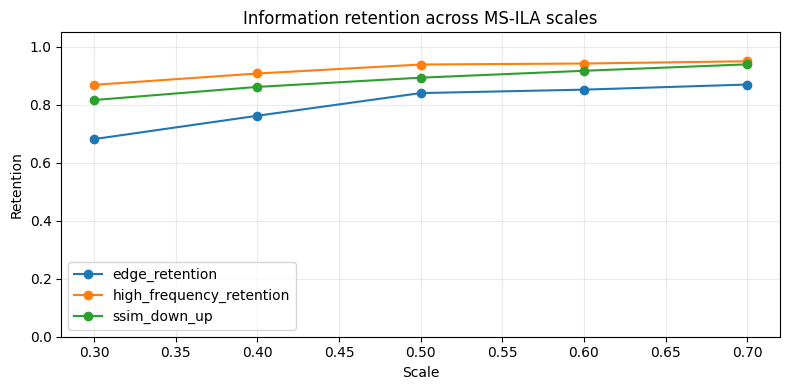

In [ ]:
if len(scale_retention):
    s = scale_retention.groupby("scale")[
        ["edge_retention", "high_frequency_retention", "ssim_down_up"]
    ].mean()

    plt.figure(figsize=(8, 4))
    for col in s.columns:
        plt.plot(s.index, s[col], marker="o", label=col)

    plt.xlabel("Scale")
    plt.ylabel("Retention")
    plt.title("Information retention across MS-ILA scales")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

# PHẦN VI — Photometric invariance proxy

Không tải backbone ở bước EDA.  
Ta dùng HOG-like gradient orientation descriptor để so:

- single-scale;
- multi-scale concat.

Perturbation không đổi hình học:
- brightness ×0.7 / ×1.3;
- gamma 0.7 / 1.5;
- contrast 0.7 / 1.3.

Metric: cosine similarity giữa descriptor ảnh gốc và ảnh perturb.

Nếu similarity giảm rõ, dữ liệu hỗ trợ nhu cầu học illumination invariance.  
Nếu multi-scale không tự ổn định hơn, novelty không thể chỉ là “stack nhiều scale”.

## 23. Single-scale vs multi-scale photometric stability

In [ ]:
PHOTOMETRIC_PERTURBATIONS = {
    "brightness_0.7": ("brightness", 0.7),
    "brightness_1.3": ("brightness", 1.3),
    "gamma_0.7": ("gamma", 0.7),
    "gamma_1.5": ("gamma", 1.5),
    "contrast_0.7": ("contrast", 0.7),
    "contrast_1.3": ("contrast", 1.3),
}

def apply_photometric(rgb_f, kind, value):
    x = np.clip(rgb_f, 0, 1)

    if kind == "brightness":
        return np.clip(x * value, 0, 1)

    if kind == "gamma":
        return np.clip(np.power(x, value), 0, 1)

    if kind == "contrast":
        mu = x.mean(axis=(0, 1), keepdims=True)
        return np.clip((x - mu) * value + mu, 0, 1)

    raise ValueError(kind)

def hog_like_descriptor(rgb_f, scale=1.0, bins=9, target_side=256):
    h, w = rgb_f.shape[:2]
    base = target_side / max(h, w)
    final_scale = base * scale

    nh = max(16, int(round(h*final_scale)))
    nw = max(16, int(round(w*final_scale)))

    x = cv2.resize(rgb_f, (nw, nh), interpolation=cv2.INTER_AREA)

    gray = (
        0.2126*x[...,0] +
        0.7152*x[...,1] +
        0.0722*x[...,2]
    ).astype(np.float32)

    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)

    mag = np.sqrt(gx*gx + gy*gy)
    ori = (np.arctan2(gy, gx) + np.pi) % np.pi

    hist, _ = np.histogram(
        ori,
        bins=bins,
        range=(0, np.pi),
        weights=mag
    )

    hist = hist.astype(np.float32)
    hist /= np.linalg.norm(hist) + 1e-8
    return hist

def single_scale_descriptor(rgb_f):
    return hog_like_descriptor(rgb_f, scale=1.0)

def multi_scale_descriptor(rgb_f):
    feats = [
        hog_like_descriptor(rgb_f, scale=s)
        for s in MSILA_SCALES
    ]
    x = np.concatenate(feats).astype(np.float32)
    x /= np.linalg.norm(x) + 1e-8
    return x

def cosine_similarity(a, b):
    return float(
        np.dot(a, b) /
        ((np.linalg.norm(a) + 1e-8) *
         (np.linalg.norm(b) + 1e-8))
    )

photo_rows = []

for _, r in tqdm(advanced_sample.iterrows(), total=len(advanced_sample), desc="Photometric stability"):
    bgr = cv2.imread(str(r["path"]), cv2.IMREAD_COLOR)
    if bgr is None:
        continue

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb = resize_for_stats(rgb, 640)
    f = rgb.astype(np.float32) / 255.0

    d1 = single_scale_descriptor(f)
    dm = multi_scale_descriptor(f)

    for name, (kind, value) in PHOTOMETRIC_PERTURBATIONS.items():
        xp = apply_photometric(f, kind, value)

        photo_rows.append({
            "image_path": r["path"],
            "category": r["category"],
            "split": r["split"],
            "perturbation": name,
            "single_scale_cosine": cosine_similarity(
                d1,
                single_scale_descriptor(xp)
            ),
            "multi_scale_cosine": cosine_similarity(
                dm,
                multi_scale_descriptor(xp)
            ),
        })

photometric_stability = pd.DataFrame(photo_rows)

if len(photometric_stability):
    photometric_stability["multiscale_gain"] = (
        photometric_stability["multi_scale_cosine"] -
        photometric_stability["single_scale_cosine"]
    )

    photometric_stability.to_csv(
        OUTPUT_DIR / "photometric_invariance_proxy.csv",
        index=False
    )

    display(
        photometric_stability.groupby("perturbation")[
            ["single_scale_cosine", "multi_scale_cosine", "multiscale_gain"]
        ].agg(["mean", "median", "std"]).round(4)
    )

Photometric stability:   0%|          | 0/480 [00:00<?, ?it/s]

single_scale_cosine                 multi_scale_cosine          \
                              mean  median     std               mean  median   
perturbation                                                                    
brightness_0.7              1.0000  1.0000  0.0000             1.0000  1.0000   
brightness_1.3              0.9978  0.9999  0.0049             0.9973  0.9998   
contrast_0.7                1.0000  1.0000  0.0000             1.0000  1.0000   
contrast_1.3                0.9998  1.0000  0.0004             0.9997  0.9999   
gamma_0.7                   0.9997  0.9998  0.0003             0.9995  0.9998   
gamma_1.5                   0.9994  0.9996  0.0008             0.9993  0.9996   

                       multiscale_gain                  
                   std            mean  median     std  
perturbation                                            
brightness_0.7  0.0000         -0.0000  0.0000  0.0000  
brightness_1.3  0.0054         -0.0005 -0.0000  0.0019  
contrast_0.7    0.0000         -0.0000  0.0000  0.0000  
contrast_1.3    0.0006         -0.0001 -0.0000  0.0002  
gamma_0.7       0.0005         -0.0001 -0.0001  0.0003  
gamma_1.5       0.0008         -0.0002 -0.0001  0.0004

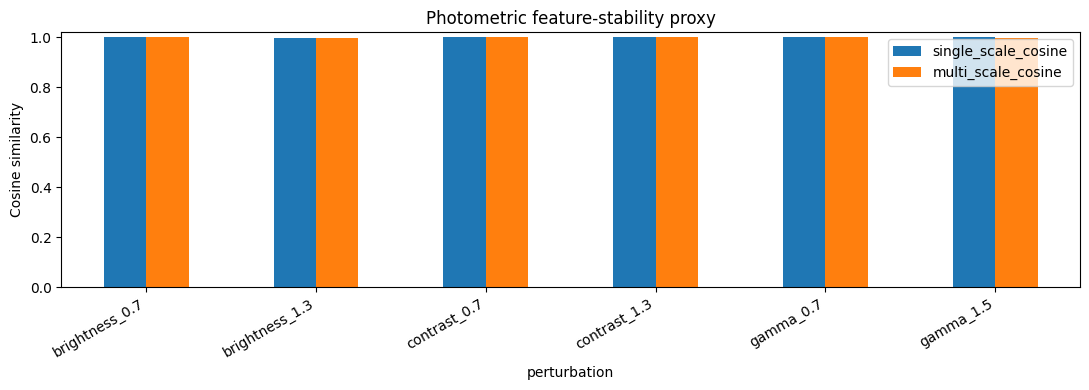

In [ ]:
if len(photometric_stability):
    p = photometric_stability.groupby("perturbation")[
        ["single_scale_cosine", "multi_scale_cosine"]
    ].mean()

    ax = p.plot(kind="bar", figsize=(11, 4))
    ax.set_ylim(0, 1.02)
    ax.set_ylabel("Cosine similarity")
    ax.set_title("Photometric feature-stability proxy")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# PHẦN VII — Tổng hợp bằng chứng cho thiết kế MS-ILA

EDA nên dẫn tới chuỗi:

**observation → hypothesis → module → ablation**

Không nên dừng ở biểu đồ mô tả.

## 24. `MS-ILA evidence` JSON

In [ ]:
evidence = {}

if len(illum_shift):
    top_shift = illum_shift.sort_values(
        "illum_shift_score",
        ascending=False
    ).head(10)

    evidence["illumination_shift_top"] = top_shift[
        ["category", "target_split", "illum_shift_score"]
    ].to_dict("records")

if len(defect_geometry):
    evidence["defect_area_ratio"] = {
        "median": float(defect_geometry["mask_area_ratio"].median()),
        "p10": float(defect_geometry["mask_area_ratio"].quantile(0.10)),
        "p90": float(defect_geometry["mask_area_ratio"].quantile(0.90)),
    }

    evidence["bbox_min_side_px"] = {
        "median": float(defect_geometry["bbox_min_side_px"].median()),
        "p10": float(defect_geometry["bbox_min_side_px"].quantile(0.10)),
        "p90": float(defect_geometry["bbox_min_side_px"].quantile(0.90)),
    }

if len(mask_survival):
    evidence["mask_survival_by_scale"] = (
        mask_survival.groupby("scale")["mask_survival_iou"]
        .median()
        .round(4)
        .to_dict()
    )

if len(scale_retention):
    evidence["image_retention_by_scale"] = (
        scale_retention.groupby("scale")[
            ["edge_retention", "high_frequency_retention"]
        ].median().round(4).to_dict()
    )

if len(photometric_stability):
    evidence["photometric_stability"] = (
        photometric_stability.groupby("perturbation")[
            ["single_scale_cosine", "multi_scale_cosine", "multiscale_gain"]
        ].mean().round(4).to_dict()
    )

with open(
    OUTPUT_DIR / "msila_eda_evidence.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(evidence, f, ensure_ascii=False, indent=2)

print(json.dumps(evidence, ensure_ascii=False, indent=2)[:15000])

{
  "illumination_shift_top": [
    {
      "category": "wallplugs",
      "target_split": "test_public",
      "illum_shift_score": 55.31083693196333
    },
    {
      "category": "wallplugs",
      "target_split": "test_private_mixed",
      "illum_shift_score": 43.96868383052599
    },
    {
      "category": "rice",
      "target_split": "test_private_mixed",
      "illum_shift_score": 4.159568752845199
    },
    {
      "category": "rice",
      "target_split": "test_public",
      "illum_shift_score": 4.041588251590726
    },
    {
      "category": "vial",
      "target_split": "test_public",
      "illum_shift_score": 2.924070742520748
    },
    {
      "category": "vial",
      "target_split": "test_private_mixed",
      "illum_shift_score": 2.4039814829244075
    },
    {
      "category": "walnuts",
      "target_split": "test_private_mixed",
      "illum_shift_score": 1.8222638939445706
    },
    {
      "category": "walnuts",
      "target_split": "test_public",
      

## 25. Bảng gợi ý ablation từ EDA

In [ ]:
recommendations = []

if len(illum_shift):
    high = illum_shift[
        illum_shift["illum_shift_score"] >=
        illum_shift["illum_shift_score"].quantile(0.75)
    ]

    recommendations.append({
        "evidence": "Illumination distribution shift",
        "observation": (
            f"{len(high)} category-split pairs ở top quartile; "
            f"max shift={illum_shift['illum_shift_score'].max():.3f}"
        ),
        "research_implication": (
            "Ablate ILA/gating theo category-split có shift cao, "
            "không chỉ báo cáo macro."
        ),
    })

if len(defect_geometry):
    p10 = defect_geometry["bbox_min_side_px"].quantile(0.10)

    recommendations.append({
        "evidence": "Small-defect geometry",
        "observation": f"P10 bbox min-side={p10:.1f}px",
        "research_implication": (
            "So sánh fine-only / coarse-only / multi-scale fusion; "
            "nếu đủ mẫu, báo cáo theo defect-size bin."
        ),
    })

if len(mask_survival):
    med = mask_survival.groupby("scale")["mask_survival_iou"].median()
    worst = med.idxmin()

    recommendations.append({
        "evidence": "Mask survival under downsampling",
        "observation": (
            f"Scale {worst:.2f}: median survival IoU={med.loc[worst]:.3f}"
        ),
        "research_implication": (
            "Không dùng coarse scale làm nguồn duy nhất; "
            "fusion cần bảo toàn fine-scale details."
        ),
    })

if len(photometric_stability):
    gain = photometric_stability["multiscale_gain"].mean()

    recommendations.append({
        "evidence": "Photometric invariance proxy",
        "observation": f"Mean multiscale gain={gain:+.4f}",
        "research_implication": (
            "Nếu gain nhỏ/âm, multi-scale tự thân không tạo invariance; "
            "cần chứng minh ILA/adaptation tạo gain."
        ),
    })

recommendations_df = pd.DataFrame(recommendations)
display(recommendations_df)

recommendations_df.to_csv(
    OUTPUT_DIR / "msila_research_recommendations.csv",
    index=False
)

,evidence,observation,research_implication
0,Illumination distribution shift,8 category-split pairs ở top quartile; max shi...,Ablate ILA/gating theo category-split có shift...
1,Small-defect geometry,P10 bbox min-side=12.0px,So sánh fine-only / coarse-only / multi-scale ...
2,Mask survival under downsampling,Scale 0.30: median survival IoU=0.841,Không dùng coarse scale làm nguồn duy nhất; fu...
3,Photometric invariance proxy,Mean multiscale gain=-0.0001,"Nếu gain nhỏ/âm, multi-scale tự thân không tạo..."


## 26. Data-card JSON

In [ ]:
summary = {
    "data_root": str(DATA_ROOT),
    "n_image_files": int(len(image_meta)),
    "n_mask_files_detected": int(len(masks_manifest)),
    "categories": categories,
    "splits_found": splits_found,
    "expected_splits": EXPECTED_SPLITS,
    "read_error_count": int((~image_meta["read_ok"]).sum()),
    "fast_mode": FAST_MODE,
    "pixel_eda_sample_size": int(len(pixel_sample)),
    "advanced_eda_sample_size": int(len(advanced_sample)),
    "msila_scales": MSILA_SCALES,
}

if len(illum_shift):
    summary["max_illum_shift"] = float(
        illum_shift["illum_shift_score"].max()
    )
    summary["mean_illum_shift"] = float(
        illum_shift["illum_shift_score"].mean()
    )

if len(defect_geometry):
    summary["median_defect_area_ratio"] = float(
        defect_geometry["mask_area_ratio"].median()
    )
    summary["median_defect_bbox_min_side_px"] = float(
        defect_geometry["bbox_min_side_px"].median()
    )

with open(
    OUTPUT_DIR / "data_card_summary.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(json.dumps(summary, ensure_ascii=False, indent=2))

{
  "data_root": "/content/drive/MyDrive/[Q3-4] 2026/[S7] Computer Vision/CV-Nhóm 9/data",
  "n_image_files": 8734,
  "n_mask_files_detected": 766,
  "categories": [
    "can",
    "fabric",
    "fruit_jelly",
    "rice",
    "sheet_metal",
    "vial",
    "wallplugs",
    "walnuts"
  ],
  "splits_found": [
    "test_private",
    "test_private_mixed",
    "test_public",
    "train",
    "validation"
  ],
  "expected_splits": [
    "train",
    "validation",
    "test_public",
    "test_private",
    "test_private_mixed"
  ],
  "read_error_count": 0,
  "fast_mode": true,
  "pixel_eda_sample_size": 1567,
  "advanced_eda_sample_size": 480,
  "msila_scales": [
    0.3,
    0.4,
    0.5,
    0.6,
    0.7
  ],
  "max_illum_shift": 55.31083693196333,
  "mean_illum_shift": 3.9916768288286093,
  "median_defect_area_ratio": 0.0014203638812295752,
  "median_defect_bbox_min_side_px": 150.0
}


## 27. Xuất `EDA_REPORT.md`

In [ ]:
report = [
    "# MVTec AD 2 — EDA Summary for MS-ILA",
    "",
    "## Dataset structure",
    f"- Images detected: {len(image_meta):,}",
    f"- Masks detected by heuristic: {len(masks_manifest):,}",
    f"- Categories: {', '.join(categories)}",
    f"- Splits found: {', '.join(splits_found)}",
    f"- Read errors: {int((~image_meta['read_ok']).sum())}",
    "",
    "## MS-ILA evidence",
]

if len(illum_shift):
    report += ["", "### Highest illumination-shift pairs"]
    top = illum_shift.sort_values(
        "illum_shift_score",
        ascending=False
    ).head(5)

    for _, r in top.iterrows():
        report.append(
            f"- {r['category']} | {r['target_split']}: "
            f"{r['illum_shift_score']:.4f}"
        )

if len(defect_geometry):
    report += [
        "",
        "### Defect geometry",
        f"- Median area ratio: {defect_geometry['mask_area_ratio'].median():.6f}",
        f"- P10 area ratio: {defect_geometry['mask_area_ratio'].quantile(0.10):.6f}",
        f"- Median bbox min-side: {defect_geometry['bbox_min_side_px'].median():.2f}px",
    ]

if len(mask_survival):
    report += ["", "### Mask survival by scale"]
    temp = mask_survival.groupby("scale")["mask_survival_iou"].median()
    for scale, val in temp.items():
        report.append(f"- scale={scale:.2f}: median IoU={val:.4f}")

if len(photometric_stability):
    report += [
        "",
        "### Photometric invariance proxy",
        f"- Mean single-scale cosine: {photometric_stability['single_scale_cosine'].mean():.4f}",
        f"- Mean multi-scale cosine: {photometric_stability['multi_scale_cosine'].mean():.4f}",
        f"- Mean multiscale gain: {photometric_stability['multiscale_gain'].mean():+.4f}",
    ]

report += [
    "",
    "## Interpretation",
    "- Đây là EDA/proxy, không thay thế benchmark hoặc model ablation.",
    "- Kết luận MS-ILA phải được xác nhận bằng validation protocol đã khóa.",
]

report_text = "\n".join(report)

report_path = OUTPUT_DIR / "EDA_REPORT.md"
report_path.write_text(report_text, encoding="utf-8")

print(report_text)
print("\nSaved:", report_path.resolve())

# MVTec AD 2 — EDA Summary for MS-ILA

## Dataset structure
- Images detected: 8,734
- Masks detected by heuristic: 766
- Categories: can, fabric, fruit_jelly, rice, sheet_metal, vial, wallplugs, walnuts
- Splits found: test_private, test_private_mixed, test_public, train, validation
- Read errors: 0

## MS-ILA evidence

### Highest illumination-shift pairs
- wallplugs | test_public: 55.3108
- wallplugs | test_private_mixed: 43.9687
- rice | test_private_mixed: 4.1596
- rice | test_public: 4.0416
- vial | test_public: 2.9241

### Defect geometry
- Median area ratio: 0.001420
- P10 area ratio: 0.000056
- Median bbox min-side: 150.00px

### Mask survival by scale
- scale=0.30: median IoU=0.8405
- scale=0.40: median IoU=0.8740
- scale=0.50: median IoU=0.9512
- scale=0.60: median IoU=0.8966
- scale=0.70: median IoU=0.8990

### Photometric invariance proxy
- Mean single-scale cosine: 0.9994
- Mean multi-scale cosine: 0.9993
- Mean multiscale gain: -0.0001

## Interpretation
- Đây là EDA/pro

Lưu lại outputs

In [ ]:
import shutil
from pathlib import Path

# Đảm bảo Drive đã được mount (Nếu bạn đã mount ở cell trên thì có thể bỏ qua 2 dòng này)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# Đường dẫn gốc của bạn
DATA_ROOT = Path('/content/drive/MyDrive/[Q3-4] 2026/[S7] Computer Vision/CV-Nhóm 9/') if IN_COLAB else Path("./data")

# 1. Định nghĩa thư mục Nguồn (trên máy ảo) và Đích (trên Drive)
SOURCE_DIR = Path('/content/outputs/')
DEST_DIR = DATA_ROOT / 'outputs_data_eda' # Lưu vào thư mục con 'outputs_saved' trong data

# 2. Thực hiện Copy
if SOURCE_DIR.exists():
    print(f"Đang copy dữ liệu...\nTừ: {SOURCE_DIR}\nĐến: {DEST_DIR}")

    # Lệnh copytree sẽ copy toàn bộ thư mục và các file bên trong.
    # dirs_exist_ok=True giúp code không bị báo lỗi nếu bạn chạy cell này nhiều lần (nó sẽ ghi đè/cập nhật file)
    shutil.copytree(SOURCE_DIR, DEST_DIR, dirs_exist_ok=True)

    print("✅ Đã lưu thư mục thành công lên Google Drive!")
else:
    print(f"❌ Lỗi: Không tìm thấy thư mục {SOURCE_DIR} trên Colab. Bạn hãy kiểm tra lại xem code tạo outputs đã chạy chưa nhé.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đang copy dữ liệu...
Từ: /content/outputs
Đến: /content/drive/MyDrive/[Q3-4] 2026/[S7] Computer Vision/CV-Nhóm 9/outputs_data_eda
✅ Đã lưu thư mục thành công lên Google Drive!


# Checklist trước khi training

- [ ] Count từng category/split đã kiểm tra.
- [ ] Không có ảnh corrupt.
- [ ] Resolution/channel/format bất thường đã xử lý.
- [ ] Image-mask pairing đã kiểm tra thủ công nếu dùng mask analysis.
- [ ] Illumination shift được báo cáo **theo category**.
- [ ] Xác định category/split có illumination shift cao để stress-test.
- [ ] Xác định defect-size distribution.
- [ ] Xác định scale nào làm mất defect/texture mạnh.
- [ ] Xác định perturbation brightness/gamma/contrast gây drift mạnh nhất.
- [ ] Không dùng private split để tune threshold/hyperparameter nếu protocol không cho phép.
- [ ] Các CSV/JSON/Markdown đã lưu trong `outputs/eda_msila/`.

## 28. Cách nối EDA với ablation MS-ILA

| EDA observation | Ablation tương ứng |
|---|---|
| Train→Mixed illumination shift cao | baseline vs +ILA trên mixed illumination |
| Defect nhỏ mất ở scale thấp | fine-only vs coarse-only vs multi-scale fusion |
| Shading non-uniformity cao | adapter có/không illumination conditioning |
| Color cast thay đổi | luminance-only vs RGB/Lab-aware adaptation |
| Feature-proxy drift dưới gamma/brightness | consistency/normalization ablation |
| Multi-scale proxy không tự tăng invariance | chứng minh ILA module, không chỉ multi-scale stacking |

**Điểm khoa học:** EDA phải dẫn tới **hypothesis → module → ablation**, không chỉ nhiều biểu đồ.

# PHẦN VIII — Week 02: High-resolution data → tiling → stitching → evaluator → frozen DINOv3

Phần này **viết tiếp trực tiếp** sau EDA và hoàn thiện các task kỹ thuật của Tuần 2.

## Những phần của notebook cũ cần chạy lại

### Bắt buộc
Chỉ cần chạy lại:

1. **§0. Cấu hình**
   - mount Google Drive;
   - đặt đúng `DATA_ROOT`.

Không bắt buộc chạy lại toàn bộ EDA phía trên, vì pipeline Week 02 có scanner/loader độc lập.

### Nên chạy lại khi muốn đối chiếu QA với EDA
- **§3. Quét dataset → manifest**
- **§5. Metadata ảnh**
- **§17. Image-mask pairing heuristic**

Các phần illumination EDA **§10–§28 không cần chạy lại** để test loader/tiling/DINOv3.

## Thứ tự chạy phần Week 02

Chạy tuần tự các mục mới:

**W2.0 → W2.1 → W2.2 → W2.3 → W2.4 → W2.5 → W2.6 → W2.7 → W2.8**

Output được ghi vào:

```text
<PROJECT_ROOT>/
├── src/
│   ├── data/
│   │   ├── loader.py
│   │   └── tiling.py
│   └── eval/
│       ├── segf1.py
│       └── aupro.py
├── tests/
│   ├── test_loader.py
│   ├── test_tiling.py
│   ├── test_masks.py
│   └── test_metrics.py
├── outputs/week02/
├── docs/week02_qa_log.md
└── docs/G1_decision_log.md
```

## W2.0 — Environment, project directories và protocol constants

In [ ]:
# Nếu Cell §0 của notebook cũ đã chạy thì DATA_ROOT đã tồn tại.
# Nếu chạy riêng phần Week 02, sửa DATA_ROOT tại đây.

from pathlib import Path
import os, sys, json, time, math, random, subprocess, textwrap
import numpy as np
import pandas as pd

if "DATA_ROOT" not in globals():
    DATA_ROOT = Path('/content/drive/MyDrive/[Q3-4] 2026/[S7] Computer Vision/CV-Nhóm 9/data') if IN_COLAB else Path("./data")


# Có thể đổi sang Google Drive nếu muốn lưu source bền vững:
# PROJECT_ROOT = Path("/content/drive/MyDrive/MSILA")DATA_ROOT = Path('/content/drive/MyDrive/[Q3-4] 2026/[S7] Computer Vision/CV-Nhóm 9/') if IN_COLAB else Path("./data")
PROJECT_ROOT = Path('/content/drive/MyDrive/[Q3-4] 2026/[S7] Computer Vision/CV-Nhóm 9/MSILA') if IN_COLAB else Path("./data")

SRC_DATA_DIR = PROJECT_ROOT / "src" / "data"
SRC_EVAL_DIR = PROJECT_ROOT / "src" / "eval"
TEST_DIR = PROJECT_ROOT / "tests"
DOCS_DIR = PROJECT_ROOT / "docs"
W2_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "week02"

for d in [SRC_DATA_DIR, SRC_EVAL_DIR, TEST_DIR, DOCS_DIR, W2_OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Tiling protocol
LOCAL_TILE_SIZE = 512
LOCAL_OVERLAP = 128
LOCAL_STRIDE = LOCAL_TILE_SIZE - LOCAL_OVERLAP   # 384
CONTEXT_SIZE = 768
CONTEXT_OUT_SIZE = 512

# DINO-style normalization.
# Trước khi khóa G1, đối chiếu lại với official transform của checkpoint DINOv3 cụ thể.
DINOV3_MEAN = (0.485, 0.456, 0.406)
DINOV3_STD  = (0.229, 0.224, 0.225)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

WEEK2_STATUS = {
    "loader": "TODO",
    "tiling": "TODO",
    "hann_stitch": "TODO",
    "mask_stitch": "TODO",
    "metrics": "TODO",
    "dinov3_smoke": "TODO",
    "end_to_end_qa": "TODO",
    "g1": "TODO",
}

print("DATA_ROOT   :", DATA_ROOT)
print("PROJECT_ROOT:", PROJECT_ROOT.resolve())
print("local/context:", LOCAL_TILE_SIZE, CONTEXT_SIZE, "stride:", LOCAL_STRIDE)

DATA_ROOT   : /content/drive/MyDrive/[Q3-4] 2026/[S7] Computer Vision/CV-Nhóm 9/data
PROJECT_ROOT: /content/drive/MyDrive/[Q3-4] 2026/[S7] Computer Vision/CV-Nhóm 9/MSILA
local/context: 512 768 stride: 384


In [ ]:
import importlib.util, subprocess, sys

required = ["pytest"]
missing = [p for p in required if importlib.util.find_spec(p) is None]

if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

print("pytest ready")

pytest ready


# W2.1 — Thứ Hai: High-resolution loader

Yêu cầu được khóa:

- ảnh được đọc ở **native resolution**;
- grayscale → **3 channel** bằng cách lặp đúng cùng một kênh;
- mask giữ đúng `H×W`, nếu cần resize chỉ dùng nearest-neighbor;
- trả metadata `category, split, H, W, path`;
- image tensor dạng `float32`, range `[0,1]`;
- đồng thời trả `image_norm` theo mean/std DINOv3;
- không resize ảnh toàn cục trong loader;
- batch native-resolution dùng `batch_size=1` hoặc `native_collate_fn`.

## W2.1.1 — Tạo `src/data/loader.py`

In [ ]:
LOADER_PY = r"""
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple
import re

import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

EXPECTED_SPLITS = {
    "train",
    "validation",
    "test_public",
    "test_private",
    "test_private_mixed",
}

MASK_DIR_TOKENS = {
    "ground_truth", "groundtruth", "gt",
    "mask", "masks", "label", "labels",
    "segmentation", "segmentations",
}

DINOV3_MEAN = (0.485, 0.456, 0.406)
DINOV3_STD = (0.229, 0.224, 0.225)


def _norm_token(x: str) -> str:
    return re.sub(r"[\s\-]+", "_", str(x).strip().lower())


def _canonical_split(part: str) -> Optional[str]:
    p = _norm_token(part)
    aliases = {
        "train": "train",
        "training": "train",
        "val": "validation",
        "valid": "validation",
        "validation": "validation",
        "test_public": "test_public",
        "testpublic": "test_public",
        "public_test": "test_public",
        "test_private": "test_private",
        "testprivate": "test_private",
        "private_test": "test_private",
        "test_private_mixed": "test_private_mixed",
        "testprivatemixed": "test_private_mixed",
        "private_mixed": "test_private_mixed",
    }
    return aliases.get(p)


def _is_mask_path(path: Path) -> bool:
    parts = [_norm_token(p) for p in path.parts]
    stem = _norm_token(path.stem)
    return (
        any(p in MASK_DIR_TOKENS for p in parts)
        or stem.endswith("_mask")
        or stem.endswith("_gt")
        or stem.endswith("_label")
    )


def _canonical_stem(stem: str) -> str:
    s = _norm_token(stem)
    for suffix in ("_mask", "_gt", "_label", "_seg", "_segmentation"):
        if s.endswith(suffix):
            s = s[:-len(suffix)]
    return s


@dataclass(frozen=True)
class SampleRecord:
    image_path: str
    category: str
    split: str
    mask_path: Optional[str]


def scan_mvtec_ad2(data_root: str | Path) -> List[SampleRecord]:
    root = Path(data_root)
    if not root.exists():
        raise FileNotFoundError(f"DATA_ROOT does not exist: {root}")

    all_files = [
        p for p in root.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    ]

    images = []
    masks = []

    for p in all_files:
        rel = p.relative_to(root)
        parts = list(rel.parts)

        split = None
        for part in parts:
            s = _canonical_split(part)
            if s is not None:
                split = s
                break

        if split is None:
            continue

        category = parts[0] if parts else "unknown"

        item = {
            "path": str(p),
            "category": category,
            "split": split,
            "stem": _canonical_stem(p.stem),
        }

        if _is_mask_path(p):
            masks.append(item)
        else:
            images.append(item)

    # Pair mask conservatively by category + split + canonical stem.
    mask_index: Dict[Tuple[str, str, str], List[str]] = {}
    for m in masks:
        key = (m["category"], m["split"], m["stem"])
        mask_index.setdefault(key, []).append(m["path"])

    # Fallback index ignores split, useful when ground-truth is stored
    # under a parallel directory layout.
    mask_fallback: Dict[Tuple[str, str], List[str]] = {}
    for m in masks:
        key = (m["category"], m["stem"])
        mask_fallback.setdefault(key, []).append(m["path"])

    records = []
    for im in images:
        key = (im["category"], im["split"], im["stem"])
        candidates = mask_index.get(key, [])

        if not candidates:
            candidates = mask_fallback.get((im["category"], im["stem"]), [])

        mask_path = candidates[0] if len(candidates) == 1 else None

        records.append(
            SampleRecord(
                image_path=im["path"],
                category=im["category"],
                split=im["split"],
                mask_path=mask_path,
            )
        )

    return records


def load_rgb_native(path: str | Path) -> torch.Tensor:
    # Output: float32 [3,H,W] in [0,1].
    with Image.open(path) as im:
        arr = np.array(im)

    if arr.ndim == 2:
        arr = np.repeat(arr[..., None], 3, axis=2)
    elif arr.ndim == 3:
        if arr.shape[2] == 1:
            arr = np.repeat(arr, 3, axis=2)
        elif arr.shape[2] >= 3:
            arr = arr[..., :3]
        else:
            raise ValueError(f"Unsupported channel count: {arr.shape}")
    else:
        raise ValueError(f"Unsupported image shape: {arr.shape}")

    # Robust conversion for uint8/uint16/float.
    if np.issubdtype(arr.dtype, np.integer):
        maxv = np.iinfo(arr.dtype).max
        arr = arr.astype(np.float32) / float(maxv)
    else:
        arr = arr.astype(np.float32)
        if arr.max(initial=0.0) > 1.0:
            arr = arr / 255.0

    arr = np.clip(arr, 0.0, 1.0)
    return torch.from_numpy(arr).permute(2, 0, 1).contiguous()


def normalize_dinov3(
    image_chw: torch.Tensor,
    mean: Sequence[float] = DINOV3_MEAN,
    std: Sequence[float] = DINOV3_STD,
) -> torch.Tensor:
    if image_chw.ndim != 3 or image_chw.shape[0] != 3:
        raise ValueError(f"Expected [3,H,W], got {tuple(image_chw.shape)}")

    mean_t = torch.tensor(mean, dtype=image_chw.dtype, device=image_chw.device)[:, None, None]
    std_t = torch.tensor(std, dtype=image_chw.dtype, device=image_chw.device)[:, None, None]
    return (image_chw - mean_t) / std_t


def load_mask_native(
    path: str | Path,
    target_hw: Optional[Tuple[int, int]] = None,
) -> torch.Tensor:
    with Image.open(path) as im:
        im = im.convert("L")

        if target_hw is not None and im.size != (target_hw[1], target_hw[0]):
            im = im.resize(
                (target_hw[1], target_hw[0]),
                resample=Image.Resampling.NEAREST,
            )

        arr = np.array(im)

    mask = torch.from_numpy((arr > 0).astype(np.uint8))
    return mask


class MVTecAD2HighResDataset(Dataset):
    def __init__(
        self,
        data_root: str | Path,
        split: Optional[str] = None,
        categories: Optional[Sequence[str]] = None,
        mean: Sequence[float] = DINOV3_MEAN,
        std: Sequence[float] = DINOV3_STD,
    ):
        self.data_root = Path(data_root)
        self.mean = tuple(float(v) for v in mean)
        self.std = tuple(float(v) for v in std)

        records = scan_mvtec_ad2(self.data_root)

        if split is not None:
            records = [r for r in records if r.split == split]

        if categories is not None:
            keep = set(categories)
            records = [r for r in records if r.category in keep]

        self.records = records

        if len(self.records) == 0:
            raise RuntimeError(
                f"No samples found for split={split}, categories={categories}, root={self.data_root}"
            )

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index: int):
        rec = self.records[index]

        image = load_rgb_native(rec.image_path)
        _, h, w = image.shape

        mask = None
        if rec.mask_path is not None:
            mask = load_mask_native(rec.mask_path, target_hw=(h, w))
            if tuple(mask.shape) != (h, w):
                raise AssertionError(
                    f"Mask shape {tuple(mask.shape)} != image shape {(h,w)}"
                )

        return {
            "image": image,                         # raw [0,1], native resolution
            "image_norm": normalize_dinov3(image, self.mean, self.std),
            "mask": mask,
            "meta": {
                "category": rec.category,
                "split": rec.split,
                "H": h,
                "W": w,
                "path": rec.image_path,
                "mask_path": rec.mask_path,
            },
        }


def native_collate_fn(batch):
    # Native-resolution images may have different H,W.
    # Preserve as a Python list instead of torch.stack().
    return batch
"""

(SRC_DATA_DIR / "loader.py").write_text(LOADER_PY, encoding="utf-8")
(SRC_DATA_DIR / "__init__.py").write_text("", encoding="utf-8")
(SRC_EVAL_DIR / "__init__.py").write_text("", encoding="utf-8")
(PROJECT_ROOT / "src" / "__init__.py").write_text("", encoding="utf-8")

print("Wrote:", SRC_DATA_DIR / "loader.py")

Wrote: /content/drive/MyDrive/[Q3-4] 2026/[S7] Computer Vision/CV-Nhóm 9/MSILA/src/data/loader.py


## W2.1.2 — Unit tests loader

In [ ]:
TEST_LOADER_PY = r"""
import sys
from pathlib import Path

import numpy as np
import torch
from PIL import Image

PROJECT_ROOT = Path(__file__).resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.loader import (
    load_rgb_native,
    load_mask_native,
    normalize_dinov3,
    DINOV3_MEAN,
    DINOV3_STD,
)


def test_grayscale_to_three_channels(tmp_path):
    arr = np.arange(35, dtype=np.uint8).reshape(5, 7)
    p = tmp_path / "gray.png"
    Image.fromarray(arr, mode="L").save(p)

    x = load_rgb_native(p)

    assert x.shape == (3, 5, 7)
    assert x.dtype == torch.float32
    assert torch.allclose(x[0], x[1])
    assert torch.allclose(x[1], x[2])
    assert float(x.min()) >= 0.0
    assert float(x.max()) <= 1.0


def test_rgb_native_shape(tmp_path):
    arr = np.zeros((13, 17, 3), dtype=np.uint8)
    arr[..., 0] = 10
    arr[..., 1] = 20
    arr[..., 2] = 30

    p = tmp_path / "rgb.png"
    Image.fromarray(arr, mode="RGB").save(p)

    x = load_rgb_native(p)

    assert x.shape == (3, 13, 17)
    assert torch.isclose(x[0].mean(), torch.tensor(10/255.0), atol=1e-6)


def test_mask_nearest_neighbor_and_shape(tmp_path):
    mask = np.zeros((5, 7), dtype=np.uint8)
    mask[1:3, 2:5] = 255

    p = tmp_path / "mask.png"
    Image.fromarray(mask, mode="L").save(p)

    m = load_mask_native(p, target_hw=(10, 14))

    assert m.shape == (10, 14)
    assert set(torch.unique(m).tolist()).issubset({0, 1})


def test_dinov3_normalization():
    x = torch.zeros(3, 4, 5)

    y = normalize_dinov3(
        x,
        mean=DINOV3_MEAN,
        std=DINOV3_STD,
    )

    expected = -torch.tensor(DINOV3_MEAN) / torch.tensor(DINOV3_STD)

    assert y.shape == x.shape
    assert torch.allclose(
        y[:, 0, 0],
        expected,
        atol=1e-7,
    )
"""

(TEST_DIR / "test_loader.py").write_text(TEST_LOADER_PY, encoding="utf-8")
print("Wrote:", TEST_DIR / "test_loader.py")

Wrote: /content/drive/MyDrive/[Q3-4] 2026/[S7] Computer Vision/CV-Nhóm 9/MSILA/tests/test_loader.py


## W2.1.3 — Chạy loader tests + smoke trên MVTec AD 2 thật

In [ ]:
import os
import sys
import subprocess

env = os.environ.copy()
env["PYTEST_DISABLE_PLUGIN_AUTOLOAD"] = "1"

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pytest",
        "-q",
        str(TEST_DIR / "test_loader.py"),
    ],
    cwd=str(PROJECT_ROOT),
    env=env,
)

assert result.returncode == 0, "Loader unit tests FAILED"

WEEK2_STATUS["loader"] = "PASS"
print("W2.1 loader: PASS")

In [ ]:
# Real-data smoke test.
sys.path.insert(0, str(PROJECT_ROOT.resolve()))

from src.data.loader import MVTecAD2HighResDataset

# Ưu tiên train vì chắc chắn là split cần loader.
ds_train = MVTecAD2HighResDataset(
    DATA_ROOT,
    split="train",
    mean=DINOV3_MEAN,
    std=DINOV3_STD,
)

sample = ds_train[0]

print("meta       :", sample["meta"])
print("image      :", tuple(sample["image"].shape), sample["image"].dtype,
      float(sample["image"].min()), float(sample["image"].max()))
print("image_norm :", tuple(sample["image_norm"].shape), sample["image_norm"].dtype)
print("mask       :", None if sample["mask"] is None else tuple(sample["mask"].shape))

assert sample["image"].shape[0] == 3
assert sample["image"].shape[-2:] == (
    sample["meta"]["H"],
    sample["meta"]["W"],
)
assert torch.isfinite(sample["image_norm"]).all()

print("Native-resolution real-data smoke: PASS")

# W2.2 — Thứ Ba: Local tiling 512×512 + context 768×768

Quy ước tọa độ:

\[
(x_0,y_0,x_1,y_1)
\]

với `x1`, `y1` là **exclusive boundary**, giống slicing Python:

```python
image[:, y0:y1, x0:x1]
```

- local: `512×512`;
- overlap = `128`;
- stride = `384`;
- context: `768×768` cùng tâm local;
- context được resize về `512×512`;
- context ngoài border được pad;
- toàn bộ coordinate được giữ lại trong `TileRecord`.

## W2.2.1 — Tạo `src/data/tiling.py`

In [ ]:
TILING_PY = r"""
from __future__ import annotations

from dataclasses import dataclass, asdict
from typing import Iterable, List, Sequence, Tuple

import torch
import torch.nn.functional as F


@dataclass(frozen=True)
class TileRecord:
    tile_id: int
    local_xyxy: Tuple[int, int, int, int]
    context_xyxy: Tuple[int, int, int, int]
    center_xy: Tuple[float, float]


def generate_starts(length: int, tile_size: int, overlap: int) -> List[int]:
    if length <= 0:
        raise ValueError("length must be positive")
    if tile_size <= 0:
        raise ValueError("tile_size must be positive")
    if not (0 <= overlap < tile_size):
        raise ValueError("overlap must satisfy 0 <= overlap < tile_size")

    if length <= tile_size:
        return [0]

    stride = tile_size - overlap
    starts = list(range(0, length - tile_size + 1, stride))

    last = length - tile_size
    if starts[-1] != last:
        starts.append(last)

    return starts


def generate_tile_records(
    H: int,
    W: int,
    local_size: int = 512,
    overlap: int = 128,
    context_size: int = 768,
) -> List[TileRecord]:
    ys = generate_starts(H, local_size, overlap)
    xs = generate_starts(W, local_size, overlap)

    records = []
    tile_id = 0

    for y0 in ys:
        for x0 in xs:
            local_x0 = x0
            local_y0 = y0
            local_x1 = x0 + local_size
            local_y1 = y0 + local_size

            cx = x0 + local_size / 2.0
            cy = y0 + local_size / 2.0

            context_x0 = int(round(cx - context_size / 2.0))
            context_y0 = int(round(cy - context_size / 2.0))
            context_x1 = context_x0 + context_size
            context_y1 = context_y0 + context_size

            records.append(
                TileRecord(
                    tile_id=tile_id,
                    local_xyxy=(local_x0, local_y0, local_x1, local_y1),
                    context_xyxy=(context_x0, context_y0, context_x1, context_y1),
                    center_xy=(cx, cy),
                )
            )
            tile_id += 1

    return records


def crop_with_padding(
    chw: torch.Tensor,
    xyxy: Sequence[int],
    pad_mode: str = "reflect",
    pad_value: float = 0.0,
) -> torch.Tensor:
    if chw.ndim != 3:
        raise ValueError(f"Expected CHW tensor, got {tuple(chw.shape)}")

    x0, y0, x1, y1 = map(int, xyxy)

    if x1 <= x0 or y1 <= y0:
        raise ValueError(f"Invalid box: {xyxy}")

    C, H, W = chw.shape

    ix0 = max(0, x0)
    iy0 = max(0, y0)
    ix1 = min(W, x1)
    iy1 = min(H, y1)

    crop = chw[:, iy0:iy1, ix0:ix1]

    pad_left = max(0, -x0)
    pad_top = max(0, -y0)
    pad_right = max(0, x1 - W)
    pad_bottom = max(0, y1 - H)

    if any(v > 0 for v in (pad_left, pad_right, pad_top, pad_bottom)):
        # Reflect requires input dimension > padding in some edge cases.
        # Fall back to replicate for very small images.
        effective_mode = pad_mode
        if crop.shape[-1] <= max(pad_left, pad_right) or crop.shape[-2] <= max(pad_top, pad_bottom):
            effective_mode = "replicate"

        if effective_mode == "constant":
            crop = F.pad(
                crop,
                (pad_left, pad_right, pad_top, pad_bottom),
                mode="constant",
                value=pad_value,
            )
        else:
            crop = F.pad(
                crop,
                (pad_left, pad_right, pad_top, pad_bottom),
                mode=effective_mode,
            )

    expected_h = y1 - y0
    expected_w = x1 - x0

    if tuple(crop.shape[-2:]) != (expected_h, expected_w):
        raise AssertionError(
            f"Crop shape {tuple(crop.shape[-2:])} != {(expected_h,expected_w)}"
        )

    return crop


def extract_local_context(
    image_chw: torch.Tensor,
    record: TileRecord,
    local_out_size: int = 512,
    context_out_size: int = 512,
) -> Tuple[torch.Tensor, torch.Tensor]:
    local = crop_with_padding(
        image_chw,
        record.local_xyxy,
        pad_mode="reflect",
    )

    context = crop_with_padding(
        image_chw,
        record.context_xyxy,
        pad_mode="reflect",
    )

    if tuple(local.shape[-2:]) != (local_out_size, local_out_size):
        local = F.interpolate(
            local[None],
            size=(local_out_size, local_out_size),
            mode="bilinear",
            align_corners=False,
        )[0]

    context = F.interpolate(
        context[None],
        size=(context_out_size, context_out_size),
        mode="bilinear",
        align_corners=False,
    )[0]

    return local, context


def coverage_fraction_1d(
    length: int,
    tile_size: int = 512,
    overlap: int = 128,
) -> float:
    starts = generate_starts(length, tile_size, overlap)
    covered = torch.zeros(length, dtype=torch.bool)

    for s in starts:
        a = max(0, s)
        b = min(length, s + tile_size)
        covered[a:b] = True

    return float(covered.float().mean())


def coverage_fraction_2d(
    H: int,
    W: int,
    tile_size: int = 512,
    overlap: int = 128,
) -> float:
    # Grid is Cartesian product of independent x/y starts.
    return coverage_fraction_1d(H, tile_size, overlap) * coverage_fraction_1d(W, tile_size, overlap)


def hann2d(
    size: int = 512,
    eps: float = 1e-3,
    device=None,
    dtype=torch.float32,
) -> torch.Tensor:
    w = torch.hann_window(
        size,
        periodic=False,
        dtype=dtype,
        device=device,
    )
    w2 = torch.outer(w, w)
    return w2.clamp_min(eps)


def stitch_tiles_hann(
    tile_maps: Sequence[torch.Tensor],
    records: Sequence[TileRecord],
    out_hw: Tuple[int, int],
    local_size: int = 512,
    eps: float = 1e-8,
) -> torch.Tensor:
    if len(tile_maps) != len(records):
        raise ValueError("tile_maps and records must have same length")

    H, W = map(int, out_hw)

    if len(tile_maps) == 0:
        raise ValueError("No tile maps")

    first = tile_maps[0]

    if first.ndim == 2:
        channels = None
        accum = torch.zeros((H, W), dtype=first.dtype, device=first.device)
        weight_sum = torch.zeros_like(accum)
    elif first.ndim == 3:
        channels = first.shape[0]
        accum = torch.zeros((channels, H, W), dtype=first.dtype, device=first.device)
        weight_sum = torch.zeros((1, H, W), dtype=first.dtype, device=first.device)
    else:
        raise ValueError("Each tile map must be HW or CHW")

    window = hann2d(
        local_size,
        device=first.device,
        dtype=first.dtype,
    )

    for tile, rec in zip(tile_maps, records):
        if tile.shape[-2:] != (local_size, local_size):
            mode = "bilinear"
            if tile.ndim == 2:
                tile = F.interpolate(
                    tile[None, None],
                    size=(local_size, local_size),
                    mode=mode,
                    align_corners=False,
                )[0, 0]
            else:
                tile = F.interpolate(
                    tile[None],
                    size=(local_size, local_size),
                    mode=mode,
                    align_corners=False,
                )[0]

        x0, y0, x1, y1 = rec.local_xyxy

        ox0 = max(0, x0)
        oy0 = max(0, y0)
        ox1 = min(W, x1)
        oy1 = min(H, y1)

        if ox1 <= ox0 or oy1 <= oy0:
            continue

        tx0 = ox0 - x0
        ty0 = oy0 - y0
        tx1 = tx0 + (ox1 - ox0)
        ty1 = ty0 + (oy1 - oy0)

        w_patch = window[ty0:ty1, tx0:tx1]

        if tile.ndim == 2:
            t_patch = tile[ty0:ty1, tx0:tx1]
            accum[oy0:oy1, ox0:ox1] += t_patch * w_patch
            weight_sum[oy0:oy1, ox0:ox1] += w_patch
        else:
            t_patch = tile[:, ty0:ty1, tx0:tx1]
            accum[:, oy0:oy1, ox0:ox1] += t_patch * w_patch[None]
            weight_sum[:, oy0:oy1, ox0:ox1] += w_patch[None]

    if torch.any(weight_sum <= 0):
        raise AssertionError("Found uncovered pixels during stitching")

    return accum / weight_sum.clamp_min(eps)


def crop_mask_tiles(
    mask_hw: torch.Tensor,
    records: Sequence[TileRecord],
    local_size: int = 512,
) -> List[torch.Tensor]:
    if mask_hw.ndim != 2:
        raise ValueError("mask must be HW")

    x = mask_hw[None].float()

    tiles = []
    for rec in records:
        tile = crop_with_padding(
            x,
            rec.local_xyxy,
            pad_mode="constant",
            pad_value=0.0,
        )[0]

        if tuple(tile.shape) != (local_size, local_size):
            tile = F.interpolate(
                tile[None, None],
                size=(local_size, local_size),
                mode="nearest",
            )[0, 0]

        tiles.append((tile > 0.5).to(mask_hw.dtype))

    return tiles


def stitch_mask_tiles(
    mask_tiles: Sequence[torch.Tensor],
    records: Sequence[TileRecord],
    out_hw: Tuple[int, int],
    local_size: int = 512,
) -> torch.Tensor:
    H, W = map(int, out_hw)
    out = torch.zeros((H, W), dtype=mask_tiles[0].dtype, device=mask_tiles[0].device)

    for tile, rec in zip(mask_tiles, records):
        if tile.shape != (local_size, local_size):
            tile = F.interpolate(
                tile[None, None].float(),
                size=(local_size, local_size),
                mode="nearest",
            )[0, 0].to(mask_tiles[0].dtype)

        x0, y0, x1, y1 = rec.local_xyxy

        ox0 = max(0, x0)
        oy0 = max(0, y0)
        ox1 = min(W, x1)
        oy1 = min(H, y1)

        tx0 = ox0 - x0
        ty0 = oy0 - y0
        tx1 = tx0 + (ox1 - ox0)
        ty1 = ty0 + (oy1 - oy0)

        patch = tile[ty0:ty1, tx0:tx1]
        out[oy0:oy1, ox0:ox1] = torch.maximum(
            out[oy0:oy1, ox0:ox1],
            patch,
        )

    return out
"""

(SRC_DATA_DIR / "tiling.py").write_text(TILING_PY, encoding="utf-8")
print("Wrote:", SRC_DATA_DIR / "tiling.py")

## W2.2.2 — Coverage tests + local/context shape tests

In [ ]:
TEST_TILING_PY = r"""
import sys
from pathlib import Path

import torch

PROJECT_ROOT = Path(__file__).resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.tiling import (
    generate_tile_records,
    coverage_fraction_2d,
    extract_local_context,
    stitch_tiles_hann,
)


def test_coverage_multiple_resolutions():
    sizes = [
        (320, 480),
        (512, 512),
        (513, 777),
        (768, 1024),
        (1200, 1600),
        (2048, 2448),
    ]

    for H, W in sizes:
        cov = coverage_fraction_2d(
            H,
            W,
            tile_size=512,
            overlap=128,
        )
        assert cov == 1.0


def test_local_context_shapes_and_coordinates():
    H, W = 900, 1300
    image = torch.rand(3, H, W)

    records = generate_tile_records(
        H,
        W,
        local_size=512,
        overlap=128,
        context_size=768,
    )

    assert len(records) > 0

    for rec in records[:5]:
        local, context = extract_local_context(
            image,
            rec,
            local_out_size=512,
            context_out_size=512,
        )
        assert local.shape == (3, 512, 512)
        assert context.shape == (3, 512, 512)


def test_hann_reconstruction_error():
    sizes = [
        (320, 480),
        (513, 777),
        (768, 1024),
        (1025, 1537),
    ]

    for H, W in sizes:
        # Smooth synthetic field + random component.
        torch.manual_seed(0)
        source = torch.rand(H, W)

        records = generate_tile_records(
            H,
            W,
            local_size=512,
            overlap=128,
            context_size=768,
        )

        tile_maps = []
        padded = source[None]

        from src.data.tiling import crop_with_padding

        for rec in records:
            tile = crop_with_padding(
                padded,
                rec.local_xyxy,
                pad_mode="constant",
                pad_value=0.0,
            )[0]
            tile_maps.append(tile)

        recon = stitch_tiles_hann(
            tile_maps,
            records,
            out_hw=(H, W),
            local_size=512,
        )

        err = torch.max(torch.abs(recon - source)).item()
        assert err < 1e-5, (H, W, err)
"""

(TEST_DIR / "test_tiling.py").write_text(TEST_TILING_PY, encoding="utf-8")
print("Wrote:", TEST_DIR / "test_tiling.py")

In [ ]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", str(TEST_DIR / "test_tiling.py")],
    cwd=str(PROJECT_ROOT),
    capture_output=True,
    text=True,
)

print(result.stdout)
if result.stderr:
    print(result.stderr)

assert result.returncode == 0, "Tiling/Hann tests FAILED"

WEEK2_STATUS["tiling"] = "PASS"
WEEK2_STATUS["hann_stitch"] = "PASS"

print("W2.2 tiling: PASS")
print("W2.3 Hann reconstruction: PASS")

## W2.2.3 — Audit coverage trên toàn bộ resolution thật + xuất toàn bộ tọa độ tile/context

In [ ]:
from PIL import Image
from src.data.loader import scan_mvtec_ad2
from src.data.tiling import generate_tile_records, coverage_fraction_2d

all_records = scan_mvtec_ad2(DATA_ROOT)

tile_index_rows = []
coverage_rows = []

for rec in tqdm(all_records, desc="Building tile coordinate index"):
    with Image.open(rec.image_path) as im:
        W, H = im.size

    cov = coverage_fraction_2d(
        H, W,
        tile_size=LOCAL_TILE_SIZE,
        overlap=LOCAL_OVERLAP,
    )

    coverage_rows.append({
        "category": rec.category,
        "split": rec.split,
        "path": rec.image_path,
        "H": H,
        "W": W,
        "coverage": cov,
    })

    tiles = generate_tile_records(
        H, W,
        local_size=LOCAL_TILE_SIZE,
        overlap=LOCAL_OVERLAP,
        context_size=CONTEXT_SIZE,
    )

    for t in tiles:
        lx0, ly0, lx1, ly1 = t.local_xyxy
        cx0, cy0, cx1, cy1 = t.context_xyxy
        ccx, ccy = t.center_xy

        tile_index_rows.append({
            "category": rec.category,
            "split": rec.split,
            "path": rec.image_path,
            "H": H,
            "W": W,
            "tile_id": t.tile_id,
            "local_x0": lx0,
            "local_y0": ly0,
            "local_x1": lx1,
            "local_y1": ly1,
            "context_x0": cx0,
            "context_y0": cy0,
            "context_x1": cx1,
            "context_y1": cy1,
            "center_x": ccx,
            "center_y": ccy,
        })

coverage_df = pd.DataFrame(coverage_rows)
tile_index_df = pd.DataFrame(tile_index_rows)

coverage_df.to_csv(W2_OUTPUT_DIR / "coverage_audit.csv", index=False)
tile_index_df.to_csv(W2_OUTPUT_DIR / "tile_coordinates.csv", index=False)

display(coverage_df["coverage"].describe())
print("Min coverage:", coverage_df["coverage"].min())
print("Total tiles :", len(tile_index_df))

assert np.allclose(coverage_df["coverage"].values, 1.0)

print("Real-dataset coverage = 100%: PASS")

# W2.3 — Thứ Tư: Hann stitching

Implementation nằm trong `src/data/tiling.py`:

- `hann2d()`
- `stitch_tiles_hann()`

Unit test ở `tests/test_tiling.py` đã thực hiện:

```text
synthetic image
→ tile
→ Hann weighted stitch
→ compare pixel-wise với source
```

với nhiều resolution và yêu cầu:

\[
\max |I_\text{recon}-I_\text{source}| < 10^{-5}.
\]

Cell dưới lưu thêm một visual QA về seam.

In [ ]:
import matplotlib.pyplot as plt
import torch

from src.data.tiling import (
    generate_tile_records,
    crop_with_padding,
    stitch_tiles_hann,
)

H, W = 773, 1199
yy = torch.linspace(0, 1, H)[:, None]
xx = torch.linspace(0, 1, W)[None, :]
synthetic = 0.55 * xx + 0.45 * yy

records = generate_tile_records(
    H, W,
    local_size=LOCAL_TILE_SIZE,
    overlap=LOCAL_OVERLAP,
    context_size=CONTEXT_SIZE,
)

tile_maps = [
    crop_with_padding(
        synthetic[None],
        r.local_xyxy,
        pad_mode="constant",
        pad_value=0.0,
    )[0]
    for r in records
]

reconstructed = stitch_tiles_hann(
    tile_maps,
    records,
    out_hw=(H, W),
    local_size=LOCAL_TILE_SIZE,
)

error_map = torch.abs(reconstructed - synthetic)
max_err = float(error_map.max())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].imshow(synthetic.numpy(), cmap="gray")
axes[0].set_title("Synthetic source")
axes[1].imshow(reconstructed.numpy(), cmap="gray")
axes[1].set_title("Hann reconstruction")
axes[2].imshow(error_map.numpy(), cmap="magma")
axes[2].set_title(f"|error|, max={max_err:.2e}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
qa_path = W2_OUTPUT_DIR / "hann_stitch_visual_qa.png"
plt.savefig(qa_path, dpi=160, bbox_inches="tight")
plt.show()

assert max_err < 1e-5
print("Saved:", qa_path)

# W2.4 — Thứ Năm: Mask crop/stitch

Yêu cầu:

- crop mask theo cùng coordinate local tile;
- padding = 0;
- mọi resize mask dùng **nearest-neighbor**;
- stitch bằng phép OR/max;
- reconstructed IoU phải bằng `1.0`.

Test gồm:
1. anomaly rất nhỏ;
2. anomaly sát border;
3. anomaly cắt qua nhiều tile.

In [ ]:
TEST_MASKS_PY = r"""
import sys
from pathlib import Path

import torch

PROJECT_ROOT = Path(__file__).resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.tiling import (
    generate_tile_records,
    crop_mask_tiles,
    stitch_mask_tiles,
)


def iou(a, b):
    a = a > 0
    b = b > 0
    inter = torch.logical_and(a, b).sum().item()
    union = torch.logical_or(a, b).sum().item()
    return inter / union if union else 1.0


def _roundtrip(mask):
    H, W = mask.shape

    records = generate_tile_records(
        H, W,
        local_size=512,
        overlap=128,
        context_size=768,
    )

    tiles = crop_mask_tiles(
        mask,
        records,
        local_size=512,
    )

    recon = stitch_mask_tiles(
        tiles,
        records,
        out_hw=(H, W),
        local_size=512,
    )

    return recon


def test_small_anomaly():
    mask = torch.zeros(900, 1300, dtype=torch.uint8)
    mask[451:454, 711:715] = 1

    recon = _roundtrip(mask)

    assert torch.equal(recon, mask)
    assert iou(recon, mask) == 1.0


def test_border_anomaly():
    mask = torch.zeros(777, 999, dtype=torch.uint8)
    mask[0:15, 0:21] = 1
    mask[-13:, -17:] = 1

    recon = _roundtrip(mask)

    assert torch.equal(recon, mask)
    assert iou(recon, mask) == 1.0


def test_anomaly_crossing_multiple_tiles():
    mask = torch.zeros(1200, 1600, dtype=torch.uint8)

    # Cross both x and y tile boundaries.
    mask[360:850, 350:1100] = 1

    recon = _roundtrip(mask)

    assert torch.equal(recon, mask)
    assert iou(recon, mask) == 1.0
"""

(TEST_DIR / "test_masks.py").write_text(TEST_MASKS_PY, encoding="utf-8")
print("Wrote:", TEST_DIR / "test_masks.py")

In [ ]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", str(TEST_DIR / "test_masks.py")],
    cwd=str(PROJECT_ROOT),
    capture_output=True,
    text=True,
)

print(result.stdout)
if result.stderr:
    print(result.stderr)

assert result.returncode == 0, "Mask crop/stitch tests FAILED"

WEEK2_STATUS["mask_stitch"] = "PASS"
print("W2.4 mask reconstruction IoU=1.0: PASS")

# W2.5 — Thứ Sáu: SegF1 + AU-PRO evaluator

Evaluator có các nguyên tắc:

- shape GT/anomaly map phải khớp;
- anomaly map phải finite;
- mặc định yêu cầu score range `[0,1]`;
- SegF1 nhận threshold rõ ràng;
- trả `TP/FP/FN/precision/recall/F1`;
- có threshold search dành cho **validation only**;
- AU-PRO tích phân PRO theo FPR từ `0 → 0.05`;
- aggregation theo category rồi macro.

> Không dùng private test để chọn threshold.

## W2.5.1 — `src/eval/segf1.py`

In [ ]:
SEGF1_PY = r"""
from __future__ import annotations

from typing import Dict, Iterable, Mapping, Sequence
import numpy as np


def _as_array(x):
    return np.asarray(x)


def validate_segmentation_pair(
    anomaly_map,
    gt_mask,
    require_unit_range: bool = True,
):
    score = _as_array(anomaly_map).astype(np.float64)
    gt = _as_array(gt_mask)

    if score.shape != gt.shape:
        raise ValueError(
            f"Shape mismatch: anomaly_map={score.shape}, gt={gt.shape}"
        )

    if score.ndim != 2:
        raise ValueError(f"Expected HW arrays, got ndim={score.ndim}")

    if not np.isfinite(score).all():
        raise ValueError("anomaly_map contains NaN/Inf")

    if require_unit_range:
        if score.min(initial=0.0) < 0.0 or score.max(initial=0.0) > 1.0:
            raise ValueError(
                f"anomaly_map must be in [0,1], got [{score.min()}, {score.max()}]"
            )

    gt = gt > 0
    return score, gt


def segf1_stats(
    anomaly_map,
    gt_mask,
    threshold: float,
    require_unit_range: bool = True,
) -> Dict[str, float]:
    score, gt = validate_segmentation_pair(
        anomaly_map,
        gt_mask,
        require_unit_range=require_unit_range,
    )

    pred = score >= float(threshold)

    tp = int(np.logical_and(pred, gt).sum())
    fp = int(np.logical_and(pred, ~gt).sum())
    fn = int(np.logical_and(~pred, gt).sum())

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0

    denom = 2 * tp + fp + fn
    f1 = (2 * tp / denom) if denom else 1.0

    return {
        "threshold": float(threshold),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
    }


def best_threshold_f1(
    anomaly_maps: Sequence[np.ndarray],
    gt_masks: Sequence[np.ndarray],
    thresholds: Sequence[float] | None = None,
) -> Dict[str, float]:
    if len(anomaly_maps) != len(gt_masks):
        raise ValueError("anomaly_maps and gt_masks length mismatch")

    if thresholds is None:
        thresholds = np.linspace(0.0, 1.0, 501)

    best = None

    for t in thresholds:
        total_tp = total_fp = total_fn = 0

        for score, gt in zip(anomaly_maps, gt_masks):
            s = segf1_stats(score, gt, threshold=float(t))
            total_tp += s["tp"]
            total_fp += s["fp"]
            total_fn += s["fn"]

        denom = 2 * total_tp + total_fp + total_fn
        f1 = (2 * total_tp / denom) if denom else 1.0

        row = {
            "threshold": float(t),
            "tp": total_tp,
            "fp": total_fp,
            "fn": total_fn,
            "f1": float(f1),
        }

        if best is None or row["f1"] > best["f1"]:
            best = row

    return best


def aggregate_seg_f1(
    samples: Sequence[Mapping],
    threshold: float,
) -> Dict:
    # Each sample:
    # {"category": str, "anomaly_map": HW, "gt_mask": HW}
    by_cat = {}

    categories = sorted({str(s["category"]) for s in samples})

    for category in categories:
        subset = [s for s in samples if str(s["category"]) == category]

        tp = fp = fn = 0

        for item in subset:
            stats = segf1_stats(
                item["anomaly_map"],
                item["gt_mask"],
                threshold=threshold,
            )
            tp += stats["tp"]
            fp += stats["fp"]
            fn += stats["fn"]

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        denom = 2 * tp + fp + fn
        f1 = 2 * tp / denom if denom else 1.0

        by_cat[category] = {
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
        }

    macro_f1 = float(np.mean([v["f1"] for v in by_cat.values()])) if by_cat else np.nan

    return {
        "threshold": float(threshold),
        "per_category": by_cat,
        "macro_f1": macro_f1,
    }
"""

(SRC_EVAL_DIR / "segf1.py").write_text(SEGF1_PY, encoding="utf-8")
print("Wrote:", SRC_EVAL_DIR / "segf1.py")

## W2.5.2 — `src/eval/aupro.py`

In [ ]:
AUPRO_PY = r"""
from __future__ import annotations

from typing import Dict, Mapping, Sequence
import numpy as np
from scipy.ndimage import label as cc_label

from .segf1 import validate_segmentation_pair


def _sorted_component_scores(
    anomaly_maps: Sequence[np.ndarray],
    gt_masks: Sequence[np.ndarray],
):
    normal_scores = []
    components = []

    score_min = np.inf
    score_max = -np.inf

    for score, gt in zip(anomaly_maps, gt_masks):
        score, gt = validate_segmentation_pair(
            score,
            gt,
            require_unit_range=True,
        )

        score_min = min(score_min, float(score.min()))
        score_max = max(score_max, float(score.max()))

        normal_scores.append(score[~gt].ravel())

        labels, ncc = cc_label(gt.astype(np.uint8))

        for cid in range(1, ncc + 1):
            vals = score[labels == cid].ravel()

            if vals.size:
                components.append(np.sort(vals))

    if not normal_scores:
        raise ValueError("No images")

    normal_scores = np.sort(np.concatenate(normal_scores))

    if len(components) == 0:
        raise ValueError("AU-PRO requires at least one anomalous connected component")

    return normal_scores, components, score_min, score_max


def _curve(
    anomaly_maps: Sequence[np.ndarray],
    gt_masks: Sequence[np.ndarray],
    num_thresholds: int = 400,
):
    normal_scores, components, smin, smax = _sorted_component_scores(
        anomaly_maps,
        gt_masks,
    )

    span = max(smax - smin, 1e-12)

    thresholds = np.concatenate([
        [smax + span * 1e-6 + 1e-12],
        np.linspace(smax, smin, int(num_thresholds)),
        [smin - span * 1e-6 - 1e-12],
    ])

    n_normal = normal_scores.size

    fprs = []
    pros = []

    for t in thresholds:
        # Prediction: score >= threshold.
        idx = np.searchsorted(normal_scores, t, side="left")
        fp = n_normal - idx
        fpr = fp / max(n_normal, 1)

        component_recalls = []

        for vals in components:
            j = np.searchsorted(vals, t, side="left")
            predicted = vals.size - j
            component_recalls.append(predicted / vals.size)

        pro = float(np.mean(component_recalls))

        fprs.append(float(fpr))
        pros.append(pro)

    fprs = np.asarray(fprs, dtype=np.float64)
    pros = np.asarray(pros, dtype=np.float64)

    order = np.argsort(fprs)
    fprs = fprs[order]
    pros = pros[order]

    # Multiple thresholds may give same FPR. Keep maximum PRO
    # because vertical segments have zero width in integration.
    unique_fpr = []
    unique_pro = []

    for f in np.unique(fprs):
        unique_fpr.append(f)
        unique_pro.append(pros[fprs == f].max())

    return np.asarray(unique_fpr), np.asarray(unique_pro)


def aupro(
    anomaly_maps: Sequence[np.ndarray],
    gt_masks: Sequence[np.ndarray],
    max_fpr: float = 0.05,
    num_thresholds: int = 400,
    return_curve: bool = False,
):
    if len(anomaly_maps) != len(gt_masks):
        raise ValueError("anomaly_maps and gt_masks length mismatch")

    if not (0.0 < max_fpr <= 1.0):
        raise ValueError("max_fpr must be in (0,1]")

    fpr, pro = _curve(
        anomaly_maps,
        gt_masks,
        num_thresholds=num_thresholds,
    )

    # Ensure FPR=0 exists.
    if fpr[0] > 0:
        fpr = np.concatenate([[0.0], fpr])
        pro = np.concatenate([[0.0], pro])

    # Interpolate exact endpoint max_fpr.
    pro_at_max = float(np.interp(max_fpr, fpr, pro))

    keep = fpr < max_fpr
    x = np.concatenate([fpr[keep], [max_fpr]])
    y = np.concatenate([pro[keep], [pro_at_max]])

    # Ensure sorted and unique after endpoint insertion.
    order = np.argsort(x)
    x = x[order]
    y = y[order]

    area = float(np.trapz(y, x))
    normalized = area / max_fpr

    out = {
        "aupro": float(normalized),
        "max_fpr": float(max_fpr),
    }

    if return_curve:
        out["fpr"] = fpr
        out["pro"] = pro

    return out


def aggregate_aupro(
    samples: Sequence[Mapping],
    max_fpr: float = 0.05,
    num_thresholds: int = 400,
) -> Dict:
    categories = sorted({str(s["category"]) for s in samples})
    per_category = {}

    for category in categories:
        subset = [s for s in samples if str(s["category"]) == category]

        maps = [np.asarray(s["anomaly_map"]) for s in subset]
        masks = [np.asarray(s["gt_mask"]) for s in subset]

        try:
            value = aupro(
                maps,
                masks,
                max_fpr=max_fpr,
                num_thresholds=num_thresholds,
            )["aupro"]
        except ValueError as e:
            value = np.nan

        per_category[category] = float(value) if np.isfinite(value) else np.nan

    valid = [v for v in per_category.values() if np.isfinite(v)]

    return {
        "per_category": per_category,
        "macro_aupro": float(np.mean(valid)) if valid else np.nan,
        "max_fpr": float(max_fpr),
    }
"""

(SRC_EVAL_DIR / "aupro.py").write_text(AUPRO_PY, encoding="utf-8")
print("Wrote:", SRC_EVAL_DIR / "aupro.py")

## W2.5.3 — Metric unit tests

In [ ]:
TEST_METRICS_PY = r"""
import sys
from pathlib import Path

import numpy as np
import pytest

PROJECT_ROOT = Path(__file__).resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

from src.eval.segf1 import (
    segf1_stats,
    best_threshold_f1,
    aggregate_seg_f1,
)
from src.eval.aupro import (
    aupro,
    aggregate_aupro,
)


def test_segf1_tp_fp_fn():
    gt = np.array([
        [0, 1],
        [1, 0],
    ], dtype=np.uint8)

    score = np.array([
        [0.1, 0.9],
        [0.8, 0.7],
    ], dtype=np.float32)

    s = segf1_stats(score, gt, threshold=0.75)

    assert s["tp"] == 2
    assert s["fp"] == 0
    assert s["fn"] == 0
    assert s["f1"] == 1.0


def test_shape_check():
    gt = np.zeros((4, 4), dtype=np.uint8)
    score = np.zeros((5, 4), dtype=np.float32)

    with pytest.raises(ValueError):
        segf1_stats(score, gt, threshold=0.5)


def test_nan_inf_check():
    gt = np.zeros((4, 4), dtype=np.uint8)

    score_nan = np.zeros((4, 4), dtype=np.float32)
    score_nan[0, 0] = np.nan

    with pytest.raises(ValueError):
        segf1_stats(score_nan, gt, threshold=0.5)

    score_inf = np.zeros((4, 4), dtype=np.float32)
    score_inf[0, 0] = np.inf

    with pytest.raises(ValueError):
        segf1_stats(score_inf, gt, threshold=0.5)


def test_range_check():
    gt = np.zeros((4, 4), dtype=np.uint8)
    score = np.ones((4, 4), dtype=np.float32) * 1.2

    with pytest.raises(ValueError):
        segf1_stats(score, gt, threshold=0.5)


def test_best_threshold_validation_interface():
    gt = np.zeros((10, 10), dtype=np.uint8)
    gt[3:7, 3:7] = 1

    score = np.zeros((10, 10), dtype=np.float32)
    score[3:7, 3:7] = 0.9
    score[0:2, 0:2] = 0.2

    out = best_threshold_f1(
        [score],
        [gt],
        thresholds=[0.1, 0.5, 0.95],
    )

    assert out["threshold"] == 0.5
    assert out["f1"] == 1.0


def test_perfect_aupro_is_one():
    gt = np.zeros((64, 64), dtype=np.uint8)
    gt[10:20, 10:20] = 1
    gt[40:50, 42:55] = 1

    score = np.zeros((64, 64), dtype=np.float32)
    score[gt > 0] = 1.0

    out = aupro(
        [score],
        [gt],
        max_fpr=0.05,
        num_thresholds=100,
    )

    assert abs(out["aupro"] - 1.0) < 1e-6


def test_macro_aggregation():
    samples = []

    for cat in ["a", "b"]:
        gt = np.zeros((32, 32), dtype=np.uint8)
        gt[8:16, 8:16] = 1

        score = np.zeros((32, 32), dtype=np.float32)
        score[gt > 0] = 1.0

        samples.append({
            "category": cat,
            "anomaly_map": score,
            "gt_mask": gt,
        })

    f1 = aggregate_seg_f1(samples, threshold=0.5)
    ap = aggregate_aupro(samples, max_fpr=0.05, num_thresholds=100)

    assert abs(f1["macro_f1"] - 1.0) < 1e-8
    assert abs(ap["macro_aupro"] - 1.0) < 1e-6
"""

(TEST_DIR / "test_metrics.py").write_text(TEST_METRICS_PY, encoding="utf-8")
print("Wrote:", TEST_DIR / "test_metrics.py")

In [ ]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", str(TEST_DIR / "test_metrics.py")],
    cwd=str(PROJECT_ROOT),
    capture_output=True,
    text=True,
)

print(result.stdout)
if result.stderr:
    print(result.stderr)

assert result.returncode == 0, "Metric tests FAILED"

WEEK2_STATUS["metrics"] = "PASS"
print("W2.5 SegF1/AU-PRO tests: PASS")

# W2.6 — Thứ Bảy: Frozen DINOv3 smoke inference

Notebook dùng `torch.hub` để load model từ repo DINOv3.

**Trước khi chạy:**
- Internet phải hoạt động;
- nếu model name khác checkpoint bạn chọn, sửa `DINOV3_MODEL`;
- mặc định dùng model nhỏ để smoke test;
- toàn bộ parameter được khóa `requires_grad=False`;
- model chạy `eval()`.

Feature được lấy từ `model.blocks[layer_id]` bằng forward hook.  
Nếu kiến trúc checkpoint không có `blocks`, cell sẽ báo rõ để bạn điều chỉnh interface.

## W2.6.1 — DINOv3 configuration + helper

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import time

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DINOV3_REPO = "facebookresearch/dinov3"
DINOV3_MODEL = "dinov3_vits16"

# Chọn layer dự kiến. Cell tự chuyển index âm thành index thực.
DINOV3_LAYER_IDS = [-4, -2, -1]

print("DEVICE:", DEVICE)
print("DINOv3 repo/model:", DINOV3_REPO, DINOV3_MODEL)

In [ ]:
def load_frozen_dinov3(repo=DINOV3_REPO, model_name=DINOV3_MODEL, device=DEVICE):
    model = torch.hub.load(
        repo,
        model_name,
        pretrained=True,
        trust_repo=True,
    )

    model.eval()

    for p in model.parameters():
        p.requires_grad_(False)

    model.to(device)

    n_total = sum(p.numel() for p in model.parameters())
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    if n_trainable != 0:
        raise AssertionError("Backbone is not fully frozen")

    print(f"parameters: {n_total/1e6:.2f}M")
    print("trainable :", n_trainable)

    return model


def resolve_block_indices(model, layer_ids):
    if not hasattr(model, "blocks"):
        raise AttributeError(
            "This DINOv3 checkpoint does not expose model.blocks. "
            "Inspect model architecture and adapt hook target."
        )

    n = len(model.blocks)
    out = []

    for idx in layer_ids:
        j = idx if idx >= 0 else n + idx

        if not (0 <= j < n):
            raise IndexError(f"layer id {idx} resolves to {j}, n_blocks={n}")

        out.append(j)

    return out


def _first_tensor(obj):
    if torch.is_tensor(obj):
        return obj

    if isinstance(obj, (tuple, list)):
        for x in obj:
            t = _first_tensor(x)
            if t is not None:
                return t

    if isinstance(obj, dict):
        for x in obj.values():
            t = _first_tensor(x)
            if t is not None:
                return t

    return None


@torch.no_grad()
def forward_with_block_features(model, x, layer_ids):
    resolved = resolve_block_indices(model, layer_ids)
    feats = {}
    handles = []

    for j in resolved:
        def _hook(module, inputs, output, j=j):
            t = _first_tensor(output)
            if t is None:
                raise RuntimeError(f"No tensor output found at block {j}")
            feats[j] = t.detach()

        handles.append(model.blocks[j].register_forward_hook(_hook))

    try:
        _ = model(x)
    finally:
        for h in handles:
            h.remove()

    missing = [j for j in resolved if j not in feats]
    if missing:
        raise RuntimeError(f"Missing hooked features: {missing}")

    return {j: feats[j] for j in resolved}


def normalize_batch_dinov3(x_bchw):
    mean = torch.tensor(DINOV3_MEAN, device=x_bchw.device, dtype=x_bchw.dtype)[None, :, None, None]
    std = torch.tensor(DINOV3_STD, device=x_bchw.device, dtype=x_bchw.dtype)[None, :, None, None]
    return (x_bchw - mean) / std


def feature_tensor_to_spatial_map(feat):
    # Return BCHW.
    if feat.ndim == 4:
        return feat

    if feat.ndim != 3:
        raise ValueError(f"Expected BNC or BCHW feature, got {tuple(feat.shape)}")

    B, N, C = feat.shape

    side = int(round(math.sqrt(N)))

    if side * side == N:
        tokens = feat
    else:
        side1 = int(round(math.sqrt(N - 1)))

        if side1 * side1 == (N - 1):
            tokens = feat[:, 1:, :]
            side = side1
        else:
            raise ValueError(
                f"Cannot infer square token grid from N={N}. "
                "Handle register/class tokens explicitly for this checkpoint."
            )

    return tokens.transpose(1, 2).reshape(B, C, side, side)

## W2.6.2 — Load model + one local/context pair + feature shape/runtime/VRAM

In [ ]:
from src.data.tiling import generate_tile_records, extract_local_context
from src.data.loader import MVTecAD2HighResDataset

dinov3 = load_frozen_dinov3()

# Dùng một ảnh native-resolution thật.
ds_smoke = MVTecAD2HighResDataset(DATA_ROOT, split="train")
s = ds_smoke[0]

image_raw = s["image"]
H, W = image_raw.shape[-2:]

tile_records = generate_tile_records(
    H, W,
    local_size=LOCAL_TILE_SIZE,
    overlap=LOCAL_OVERLAP,
    context_size=CONTEXT_SIZE,
)

local, context = extract_local_context(
    image_raw,
    tile_records[0],
    local_out_size=LOCAL_TILE_SIZE,
    context_out_size=CONTEXT_OUT_SIZE,
)

batch = torch.stack([local, context], dim=0).to(DEVICE)
batch = normalize_batch_dinov3(batch)

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

t0 = time.perf_counter()

features = forward_with_block_features(
    dinov3,
    batch,
    DINOV3_LAYER_IDS,
)

if DEVICE.type == "cuda":
    torch.cuda.synchronize()

elapsed = time.perf_counter() - t0

peak_vram_mb = (
    torch.cuda.max_memory_allocated() / (1024**2)
    if DEVICE.type == "cuda"
    else np.nan
)

feature_rows = []

for layer, feat in features.items():
    finite = bool(torch.isfinite(feat).all().item())

    feature_rows.append({
        "layer": layer,
        "shape": str(tuple(feat.shape)),
        "dtype": str(feat.dtype),
        "finite": finite,
    })

feature_shape_df = pd.DataFrame(feature_rows)
feature_shape_df["runtime_pair_s"] = elapsed
feature_shape_df["peak_vram_mb"] = peak_vram_mb

display(feature_shape_df)

feature_shape_df.to_csv(
    W2_OUTPUT_DIR / "dinov3_smoke_feature_shapes.csv",
    index=False,
)

assert feature_shape_df["finite"].all()

WEEK2_STATUS["dinov3_smoke"] = "PASS"

print(f"Runtime local+context: {elapsed:.4f}s")
print(f"Peak VRAM           : {peak_vram_mb:.1f} MB")
print("Frozen DINOv3 smoke inference: PASS")

# W2.7 — Thứ Bảy: End-to-end QA

Pipeline:

```text
native image
→ local/context tile
→ DINOv3 frozen
→ selected block feature
→ feature-norm map giả lập
→ local/context fusion đơn giản cho QA
→ resize map về 512
→ Hann stitch
→ validate shape/range/finite
→ evaluator nếu có GT mask
```

**Quan trọng:** `feature-norm map` ở đây chỉ để QA pipeline, **không phải anomaly head của MS-ILA** và không dùng để kết luận chất lượng mô hình.

Mặc định chạy `20` ảnh. Có thể tăng `QA_N_IMAGES=50`.

## W2.7.1 — QA helper

In [ ]:
from src.data.tiling import (
    generate_tile_records,
    extract_local_context,
    stitch_tiles_hann,
)

def minmax01(x, eps=1e-8):
    x = x.float()
    mn = x.amin(dim=(-2, -1), keepdim=True)
    mx = x.amax(dim=(-2, -1), keepdim=True)
    return (x - mn) / (mx - mn + eps)


@torch.no_grad()
def qa_feature_map_batch(model, raw_tiles_bchw, layer_ids):
    # raw tiles: [B,3,512,512] in [0,1].
    x = normalize_batch_dinov3(raw_tiles_bchw)
    feats = forward_with_block_features(model, x, layer_ids)

    last_layer = sorted(feats.keys())[-1]
    spatial = feature_tensor_to_spatial_map(feats[last_layer])

    # Placeholder map = L2 norm over channels.
    amap = torch.linalg.vector_norm(spatial.float(), dim=1, keepdim=True)

    amap = F.interpolate(
        amap,
        size=(LOCAL_TILE_SIZE, LOCAL_TILE_SIZE),
        mode="bilinear",
        align_corners=False,
    )[:, 0]

    amap = minmax01(amap)

    return amap, last_layer, spatial


@torch.no_grad()
def run_image_pipeline_qa(
    model,
    sample,
    layer_ids=DINOV3_LAYER_IDS,
    pair_batch_size=4,
):
    image = sample["image"]
    H, W = image.shape[-2:]

    records = generate_tile_records(
        H, W,
        local_size=LOCAL_TILE_SIZE,
        overlap=LOCAL_OVERLAP,
        context_size=CONTEXT_SIZE,
    )

    tile_maps = []
    first_local = None
    first_context = None

    for start in range(0, len(records), pair_batch_size):
        chunk = records[start:start + pair_batch_size]

        pair_tensors = []

        for rec in chunk:
            local, context = extract_local_context(
                image,
                rec,
                local_out_size=LOCAL_TILE_SIZE,
                context_out_size=CONTEXT_OUT_SIZE,
            )

            if first_local is None:
                first_local = local.detach().cpu()
                first_context = context.detach().cpu()

            pair_tensors.extend([local, context])

        x = torch.stack(pair_tensors).to(DEVICE)

        maps, layer, spatial = qa_feature_map_batch(
            model,
            x,
            layer_ids,
        )

        # pair layout = local0,context0,local1,context1,...
        for j in range(len(chunk)):
            local_map = maps[2*j]
            context_map = maps[2*j + 1]

            # QA-only fusion. Not the MS-ILA fusion module.
            fused = 0.5 * local_map + 0.5 * context_map
            tile_maps.append(fused.detach().cpu())

    stitched = stitch_tiles_hann(
        tile_maps,
        records,
        out_hw=(H, W),
        local_size=LOCAL_TILE_SIZE,
    )

    stitched = minmax01(stitched[None])[0]

    if tuple(stitched.shape) != (H, W):
        raise AssertionError("Stitched map shape mismatch")

    if not torch.isfinite(stitched).all():
        raise AssertionError("NaN/Inf in stitched anomaly map")

    if float(stitched.min()) < -1e-6 or float(stitched.max()) > 1.0 + 1e-6:
        raise AssertionError("Stitched map outside [0,1]")

    return {
        "stitched_map": stitched,
        "records": records,
        "first_local": first_local,
        "first_context": first_context,
    }

## W2.7.2 — Chạy 20–50 ảnh visual QA

In [ ]:
import matplotlib.pyplot as plt
from src.data.loader import MVTecAD2HighResDataset

QA_N_IMAGES = 20       # đổi 50 nếu GPU/time cho phép
QA_PAIR_BATCH_SIZE = 4
QA_SPLIT = "validation"

# Nếu validation không có dữ liệu thì fallback train.
try:
    qa_ds = MVTecAD2HighResDataset(DATA_ROOT, split=QA_SPLIT)
except Exception:
    QA_SPLIT = "train"
    qa_ds = MVTecAD2HighResDataset(DATA_ROOT, split=QA_SPLIT)

n_qa = min(QA_N_IMAGES, len(qa_ds))

qa_rows = []
metric_samples = []

for i in tqdm(range(n_qa), desc="End-to-end visual QA"):
    sample = qa_ds[i]

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    t0 = time.perf_counter()

    out = run_image_pipeline_qa(
        dinov3,
        sample,
        pair_batch_size=QA_PAIR_BATCH_SIZE,
    )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - t0

    stitched = out["stitched_map"]
    meta = sample["meta"]

    qa_rows.append({
        "index": i,
        "category": meta["category"],
        "split": meta["split"],
        "H": meta["H"],
        "W": meta["W"],
        "n_tiles": len(out["records"]),
        "runtime_s": elapsed,
        "map_min": float(stitched.min()),
        "map_max": float(stitched.max()),
        "finite": bool(torch.isfinite(stitched).all()),
    })

    # Lưu visual QA.
    image_np = sample["image"].permute(1, 2, 0).numpy()
    local_np = out["first_local"].permute(1, 2, 0).numpy()
    context_np = out["first_context"].permute(1, 2, 0).numpy()

    has_mask = sample["mask"] is not None
    ncols = 5 if has_mask else 4

    fig, axes = plt.subplots(1, ncols, figsize=(4*ncols, 4))

    axes[0].imshow(image_np)
    axes[0].set_title("Native image")

    axes[1].imshow(local_np)
    axes[1].set_title("Local 512")

    axes[2].imshow(context_np)
    axes[2].set_title("Context 768→512")

    axes[3].imshow(stitched.numpy(), cmap="magma")
    axes[3].set_title("Feature QA → Hann stitch")

    if has_mask:
        axes[4].imshow(sample["mask"].numpy(), cmap="gray")
        axes[4].set_title("GT mask")

        metric_samples.append({
            "category": meta["category"],
            "anomaly_map": stitched.numpy().astype(np.float32),
            "gt_mask": sample["mask"].numpy().astype(np.uint8),
        })

    for ax in axes:
        ax.axis("off")

    fig.suptitle(
        f"{meta['category']} | {meta['split']} | "
        f"{meta['H']}×{meta['W']} | {len(out['records'])} tiles",
        fontsize=11,
    )

    plt.tight_layout()

    fig_path = W2_OUTPUT_DIR / f"qa_{i:03d}_{meta['category']}.png"
    plt.savefig(fig_path, dpi=130, bbox_inches="tight")
    plt.close(fig)

qa_df = pd.DataFrame(qa_rows)
qa_df.to_csv(W2_OUTPUT_DIR / "end_to_end_qa.csv", index=False)

display(qa_df)

assert qa_df["finite"].all()
assert (qa_df["map_min"] >= -1e-6).all()
assert (qa_df["map_max"] <= 1.0 + 1e-6).all()

WEEK2_STATUS["end_to_end_qa"] = "PASS"

print(f"Saved {n_qa} QA images to:", W2_OUTPUT_DIR)
print("End-to-end pipeline QA: PASS")

## W2.7.3 — Evaluator interface smoke trên các ảnh QA có GT

Các số này **không phải benchmark** vì anomaly map chỉ là feature-norm proxy.
Mục đích duy nhất là kiểm tra `stitched map → evaluator`.

In [ ]:
from src.eval.segf1 import aggregate_seg_f1
from src.eval.aupro import aggregate_aupro

if len(metric_samples) > 0:
    # Fixed threshold chỉ để test interface.
    qa_f1 = aggregate_seg_f1(
        metric_samples,
        threshold=0.5,
    )

    print("QA-only macro SegF1:", qa_f1["macro_f1"])

    # AU-PRO cần ít nhất một anomalous connected component.
    try:
        qa_aupro = aggregate_aupro(
            metric_samples,
            max_fpr=0.05,
            num_thresholds=100,
        )
        print("QA-only macro AU-PRO@0.05:", qa_aupro["macro_aupro"])
    except Exception as e:
        print("AU-PRO QA skipped:", repr(e))

    print(
        "NOTE: các giá trị trên KHÔNG dùng để báo cáo kết quả mô hình; "
        "map hiện tại chỉ là projection giả lập."
    )
else:
    print(
        "Không có GT mask trong QA split hoặc pairing chưa tìm thấy mask. "
        "Shape/range/finite interface vẫn đã được kiểm tra."
    )

# W2.8 — Chủ Nhật: Review, khóa API và decision log G1

G1 chỉ PASS khi:

- loader tests PASS;
- coverage 100%;
- Hann reconstruction `<1e-5`;
- mask IoU `=1`;
- metric tests PASS;
- DINOv3 frozen smoke PASS;
- end-to-end QA PASS.

Cell dưới sinh:

- `docs/week02_qa_log.md`
- `docs/G1_decision_log.md`

In [ ]:
# G1 automatic gate.
required_keys = [
    "loader",
    "tiling",
    "hann_stitch",
    "mask_stitch",
    "metrics",
    "dinov3_smoke",
    "end_to_end_qa",
]

all_pass = all(WEEK2_STATUS.get(k) == "PASS" for k in required_keys)
WEEK2_STATUS["g1"] = "PASS" if all_pass else "BLOCKED"

print(json.dumps(WEEK2_STATUS, indent=2))

In [ ]:
from datetime import datetime

qa_log = f"""# Week 02 QA Log — MS-ILA

Generated: {datetime.now().isoformat(timespec="seconds")}

## Protocol

- DATA_ROOT: `{DATA_ROOT}`
- Local tile: `{LOCAL_TILE_SIZE}×{LOCAL_TILE_SIZE}`
- Local overlap: `{LOCAL_OVERLAP}`
- Local stride: `{LOCAL_STRIDE}`
- Context crop: `{CONTEXT_SIZE}×{CONTEXT_SIZE}`
- Context backbone input: `{CONTEXT_OUT_SIZE}×{CONTEXT_OUT_SIZE}`
- Coordinate convention: `(x0,y0,x1,y1)`, x1/y1 exclusive
- DINOv3 normalization mean: `{DINOV3_MEAN}`
- DINOv3 normalization std: `{DINOV3_STD}`
- DINOv3 model: `{DINOV3_REPO}:{DINOV3_MODEL}`
- Frozen backbone: yes

## Gate status

| Item | Status |
|---|---|
| High-resolution loader | {WEEK2_STATUS['loader']} |
| 512 local / 768 context tiling | {WEEK2_STATUS['tiling']} |
| Hann stitching | {WEEK2_STATUS['hann_stitch']} |
| Mask crop/stitch | {WEEK2_STATUS['mask_stitch']} |
| SegF1 + AU-PRO evaluator | {WEEK2_STATUS['metrics']} |
| Frozen DINOv3 smoke | {WEEK2_STATUS['dinov3_smoke']} |
| End-to-end visual QA | {WEEK2_STATUS['end_to_end_qa']} |
| **G1** | **{WEEK2_STATUS['g1']}** |

## Evidence files

- `outputs/week02/coverage_audit.csv`
- `outputs/week02/tile_coordinates.csv`
- `outputs/week02/hann_stitch_visual_qa.png`
- `outputs/week02/dinov3_smoke_feature_shapes.csv`
- `outputs/week02/end_to_end_qa.csv`
- `outputs/week02/qa_*.png`

## Notes

1. Feature-norm map trong end-to-end QA chỉ là projection giả lập để kiểm tra plumbing.
2. Chưa train adapter.
3. Không dùng QA-only SegF1/AU-PRO làm benchmark khoa học.
4. Threshold của benchmark sau này phải được khóa/calibrate trên validation, không tune trên private test.
"""

(DOCS_DIR / "week02_qa_log.md").write_text(qa_log, encoding="utf-8")
print(qa_log)

In [ ]:
g1_log = f"""# G1 Decision Log — Data & Feature Pipeline

## Decision

**G1 status: {WEEK2_STATUS['g1']}**

## Locked API

### Loader

Input:
- path tới ảnh MVTec AD 2.

Output:
- `image`: `float32 [3,H,W]`, native resolution, range `[0,1]`;
- `image_norm`: DINO-normalized `[3,H,W]`;
- `mask`: `uint8 [H,W]` hoặc `None`;
- metadata: `category, split, H, W, path, mask_path`.

### Coordinate convention

- `(x0,y0,x1,y1)`;
- `x1,y1` exclusive;
- local tile = `512×512`;
- overlap = `128`;
- stride = `384`;
- context = `768×768` cùng tâm local;
- context resize `768→512` trước backbone;
- border context được padding.

### Stitching

- anomaly/feature map: Hann weighted average;
- mask: binary OR/max;
- mask resize: nearest-neighbor only.

### Feature extraction

- backbone: `{DINOV3_MODEL}`;
- frozen: `requires_grad=False` cho toàn bộ backbone;
- selected block IDs: `{DINOV3_LAYER_IDS}`;
- feature extraction qua forward hook;
- downstream code không được phụ thuộc trực tiếp vào class token nếu chưa xác nhận token layout.

### Evaluator

- SegF1 threshold là explicit argument;
- threshold selection chỉ dùng validation;
- AU-PRO tích phân đến FPR `0.05`;
- báo cáo per-category và macro;
- reject NaN/Inf và shape mismatch.

## Gate criteria

- coverage = 100%;
- Hann reconstruction max error < `1e-5`;
- reconstructed mask IoU = `1.0`;
- loader/metric unit tests PASS;
- frozen DINOv3 feature finite;
- end-to-end QA finite và đúng image shape.

## Deferred to Week 03+

- adapter training;
- anomaly head chính thức;
- threshold calibration chính thức;
- benchmark SuperADD/PatchCore/DINOv3 control;
- AU-PRO/SegF1 khoa học trên benchmark.
"""

(DOCS_DIR / "G1_decision_log.md").write_text(g1_log, encoding="utf-8")
print(g1_log)

# W2.9 — Chạy toàn bộ unit tests một lần cuối

Cell cuối này là cổng kỹ thuật trước khi ghi G1 PASS.

In [ ]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", str(TEST_DIR)],
    cwd=str(PROJECT_ROOT),
    capture_output=True,
    text=True,
)

print(result.stdout)
if result.stderr:
    print(result.stderr)

assert result.returncode == 0, "Week02 test suite FAILED"

print("ALL WEEK02 UNIT TESTS: PASS")

# Mapping task tuần 2 ↔ cell mới

| Task | Cell/section |
|---|---|
| High-resolution native loader | **W2.1.1–W2.1.3** |
| grayscale → 3 channel | `src/data/loader.py::load_rgb_native()` + `test_loader.py` |
| mask đúng H×W, NN resize | `load_mask_native()` + `test_mask_nearest_neighbor_and_shape` |
| metadata category/split/H/W/path | `MVTecAD2HighResDataset.__getitem__()` |
| local 512 overlap 128 | **W2.2.1** `generate_tile_records()` |
| context 768 cùng tâm → 512 | `extract_local_context()` |
| lưu coordinate | **W2.2.3** `tile_coordinates.csv` |
| coverage 100% | `coverage_fraction_2d()` + real-data audit |
| Hann stitching | **W2.3** `stitch_tiles_hann()` |
| reconstruction `<1e-5` | `test_hann_reconstruction_error()` |
| mask crop/stitch | **W2.4** |
| mask IoU `=1.0` | `tests/test_masks.py` |
| SegF1 | **W2.5.1** |
| AU-PRO@0.05 | **W2.5.2** |
| metric tests | **W2.5.3** |
| Frozen DINOv3 smoke | **W2.6** |
| feature shape/runtime/VRAM | `dinov3_smoke_feature_shapes.csv` |
| end-to-end pipeline | **W2.7** |
| 20–50 visual QA | `outputs/week02/qa_*.png` |
| week02 QA log | **W2.8** |
| G1 decision log | **W2.8** |